# Лабораторная работа №2

In [74]:
from sklearnex import patch_sklearn
from sklearnex import config_context
patch_sklearn()
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error,r2_score,  mean_absolute_percentage_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.inspection import PartialDependenceDisplay
import numpy as np
from metrics import mse, rmse, mae, r_2, mape
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import warnings
sns.set_palette("bright")

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [75]:
data = pd.read_csv("data_sets/air.csv")
data.drop("Unnamed: 0", axis=1, inplace=True)
data

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,day_of_week,hour,year
0,0.212,0.512,0.227,0.408,0.118,0.493,0.513,0.456,0.333,0.499,0.280,0.300,3,3,18,2004
1,0.161,0.463,0.179,0.352,0.073,0.400,0.453,0.327,0.327,0.484,0.264,0.300,3,3,19,2004
2,0.178,0.542,0.171,0.342,0.093,0.498,0.451,0.371,0.297,0.564,0.276,0.300,3,3,20,2004
3,0.178,0.523,0.175,0.348,0.123,0.533,0.464,0.427,0.277,0.639,0.294,0.300,3,3,21,2004
4,0.127,0.449,0.123,0.279,0.093,0.507,0.422,0.387,0.282,0.634,0.295,0.300,3,3,22,2004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8870,0.254,0.479,0.258,0.442,0.339,0.836,0.370,0.656,0.512,0.253,0.280,0.100,4,1,10,2005
8871,0.195,0.370,0.217,0.397,0.253,0.787,0.321,0.456,0.563,0.182,0.258,0.100,4,1,11,2005
8872,0.195,0.355,0.237,0.419,0.210,0.769,0.310,0.379,0.619,0.114,0.223,0.100,4,1,12,2005
8873,0.169,0.256,0.181,0.356,0.168,0.684,0.220,0.239,0.649,0.054,0.161,0.100,4,1,13,2005


Для всех моделей в качестве таргета будем использовать `CO(GT)` - количество угарного газа в воздухе.

In [76]:
y = data["CO(GT)"]

In [77]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)
train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

In [78]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Scikit-learn", "Кастомные функции"],
    metrics
])

sklearn_and_custom_comparing = pd.DataFrame(columns=columns)
pd.options.display.float_format = '{:.3f}'.format
sklearn_and_custom_comparing

Empty DataFrame
Columns: [(Scikit-learn, R2), (Scikit-learn, MSE), (Scikit-learn, RMSE), (Scikit-learn, MAE), (Scikit-learn, MAPE), (Кастомные функции, R2), (Кастомные функции, MSE), (Кастомные функции, RMSE), (Кастомные функции, MAE), (Кастомные функции, MAPE)]
Index: []

In [79]:
def get_metrics_value(y_predict, y_test):
    sklearn_metrics = [r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error,
                       mean_absolute_percentage_error]
    custom_metrics = [r_2, mse, rmse, mae, mape]
    sklearn_metrics_results = []
    custom_metrics_results = []

    for sklearn_metric, custom_metric in zip(sklearn_metrics, custom_metrics):
        sklearn_metrics_results.append(sklearn_metric(y_test, y_predict))
        custom_metrics_results.append(custom_metric(y_test, y_predict))

    return sklearn_metrics_results, custom_metrics_results


In [80]:
def input_into_the_tables(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test,
                          sklearn_and_custom_comparing,
                          train_and_test_comparing):
    sk_learn_test_metrics, custom_test_metrics = get_metrics_value(predict_on_test_y, y_test)
    sklearn_and_custom_comparing.loc[name_of_model] = sk_learn_test_metrics + custom_test_metrics

    sk_learn_train_metrics, _ = get_metrics_value(predict_on_train_y, y_train)
    train_and_test_comparing.loc[name_of_model] = sk_learn_train_metrics + sk_learn_test_metrics


In [81]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def train_models_with_reg(X_train, y_train, reg_config):

    result={}


    for name, reg_info in reg_config.items():

        param_grid = reg_info["param_grid"]
        type_of_reg = reg_info["reg"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            cv=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            random_state=42,
            cv=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            model = type_of_reg(**trial_params)
            model.fit(X_train, y_train)
            score = cross_val_score(model, X_train, y_train, cv=3, scoring="neg_mean_squared_error").mean()
            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        optuna_model = type_of_reg(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": optuna_model,
            "best_params": study.best_params
        }

    return result

In [82]:
alpha_range = np.logspace(-3, 2).tolist()
reg_config = {
    "L1": {
        "reg": Lasso,
        "param_grid": {"alpha": alpha_range}
    },
    "L2":
        {
            "reg": Ridge,
            "param_grid": {"alpha": alpha_range}
        },
    "EN":
        {
            "reg": ElasticNet,
            "param_grid":{
                    "alpha": alpha_range,
                    "l1_ratio": np.arange(0.1, 1, 0.3).tolist()
            }

        }

}

## Простая линейная регрессия

### Простая линейная регрессия без регуляризации

Для построения модели простой линейной регрессии в качестве предикта будем использовать признак `PT08.S1(CO)` - показатели датчика S1 об уровне CO в воздухе. Выбор именно этого признака обусловлен тем, что это один из лучших показателей наличия CO в воздухе (эта зависимость была выяснена в ходе EDA).

In [83]:
X = data.drop("CO(GT)", axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_simple_train = X_train[["C6H6(GT)"]]
X_simple_test = X_test[["C6H6(GT)"]]

In [84]:
model = LinearRegression()
model.fit(X_simple_train, y_train)
simple_regression_predict_on_test_y = model.predict(X_simple_test)
simple_regression_predict_on_train_y = model.predict(X_simple_train)
model.coef_

array([0.66503398])

Text(0.5, 1.0, 'Простая регрессия')

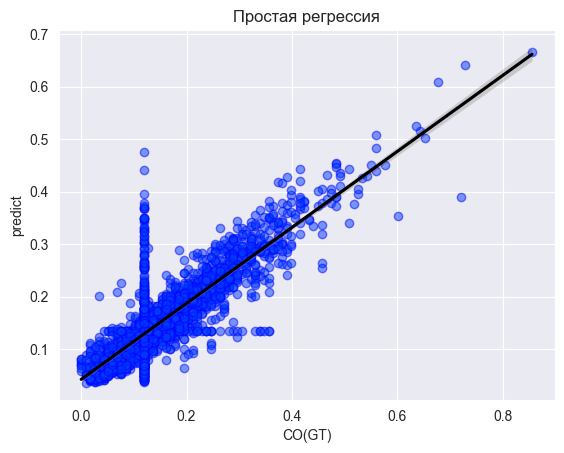

In [85]:
sns.regplot(y = simple_regression_predict_on_test_y, x = y_test,
            scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})
plt.ylabel("predict")
plt.title("Простая регрессия")

В целом модель неплохо предсказывает содержимое CO. Сравним графики распределения фактических значений целевой переменной и предсказаний.

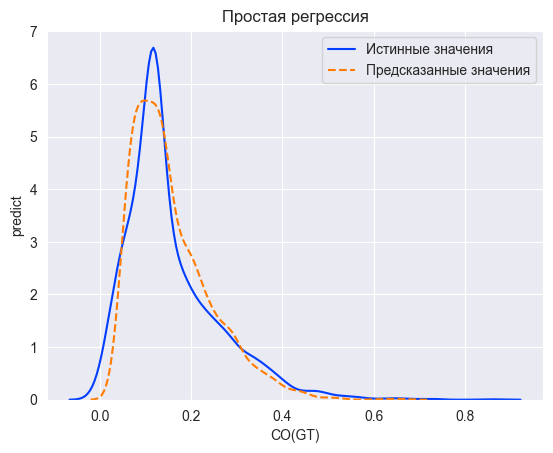

In [86]:
sns.kdeplot(y_test, label="Истинные значения")
sns.kdeplot(simple_regression_predict_on_test_y, label="Предсказанные значения", linestyle="--")
plt.ylabel("predict")
plt.title("Простая регрессия")
plt.legend()

Видим, что распределение предсказанных значений примерно повторяет основные тенденции распределения фактических значений. Стоит отметить, что модель плохо предсказывает особо высокий уровень содержания CO в воздухе, так как правый "хвост" графика распределения предсказанных значений короче правого "хвоста" фактических значений. Кроме того, пик распределения особо малых показателей CO для предсказаний не такой высокий, как для истинных значений. Это говорит о том, что модель занижает значения некоторых малых показателей.

In [87]:
input_into_the_tables("Linear regression",
                      simple_regression_predict_on_train_y, y_train,
                      simple_regression_predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

In [88]:
sklearn_and_custom_comparing.loc["Linear regression"]

Scikit-learn       R2                 0.729
                   MSE                0.003
                   RMSE               0.054
                   MAE                0.036
                   MAPE   1173507248505.241
Кастомные функции  R2                 0.729
                   MSE                0.003
                   RMSE               0.054
                   MAE                0.036
                   MAPE                 inf
Name: Linear regression, dtype: float64

In [89]:
train_and_test_comparing.loc["Linear regression"]

Train Data  R2                 0.697
            MSE                0.003
            RMSE               0.056
            MAE                0.038
            MAPE   1415233432122.305
Test Data   R2                 0.729
            MSE                0.003
            RMSE               0.054
            MAE                0.036
            MAPE   1173507248505.241
Name: Linear regression, dtype: float64

Видим, что показатели MAPE очень высокие. Это связано с тем, что перед обучением модели было проведено масштабирование с помощью MinMax, который позволил "сузить" области значений признаков и целевой переменной до отрезка (0, 1). При делении на очень малое значение получаются большие показатели MAPE.

В целом показатели метрик говорят о том, что модель делает неплохие предсказания: коэффициент R2 равен 0.729, а показатели для MSE, RMSE, MAE малы (0.03, 0.054 и 0.036).

### Применение регуляризации

In [90]:
simple_regression_reg_result = train_models_with_reg(X_simple_train, y_train, reg_config)
simple_regression_reg_result

{'L1': {'GridSearch': {'model': Lasso(alpha=0.001),
   'best_params': {'alpha': 0.001}},
  'RandomSearch': {'model': Lasso(alpha=0.021209508879201904),
   'best_params': {'alpha': 0.021209508879201904}},
  'Optuna': {'model': Lasso(alpha=0.0010013360850310467),
   'best_params': {'alpha': 0.0010013360850310467}}},
 'L2': {'GridSearch': {'model': Ridge(alpha=0.001, max_iter=1000),
   'best_params': {'alpha': 0.001}},
  'RandomSearch': {'model': Ridge(alpha=0.021209508879201904, max_iter=1000),
   'best_params': {'alpha': 0.021209508879201904}},
  'Optuna': {'model': Ridge(alpha=0.0010025593469478314),
   'best_params': {'alpha': 0.0010025593469478314}}},
 'EN': {'GridSearch': {'model': ElasticNet(alpha=0.001, l1_ratio=0.1),
   'best_params': {'alpha': 0.001, 'l1_ratio': 0.1}},
  'RandomSearch': {'model': ElasticNet(alpha=0.004094915062380427, l1_ratio=0.1),
   'best_params': {'l1_ratio': 0.1, 'alpha': 0.004094915062380427}},
  'Optuna': {'model': ElasticNet(alpha=0.0010158299180498807, 

#### L1 регуляризация

C:\Users\79585\AppData\Local\Temp\ipykernel_14604\890667732.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(predict_on_test, label="Предсказанные значения", ax=ax, linestyle="--")


Text(0.5, 0.98, 'L1')

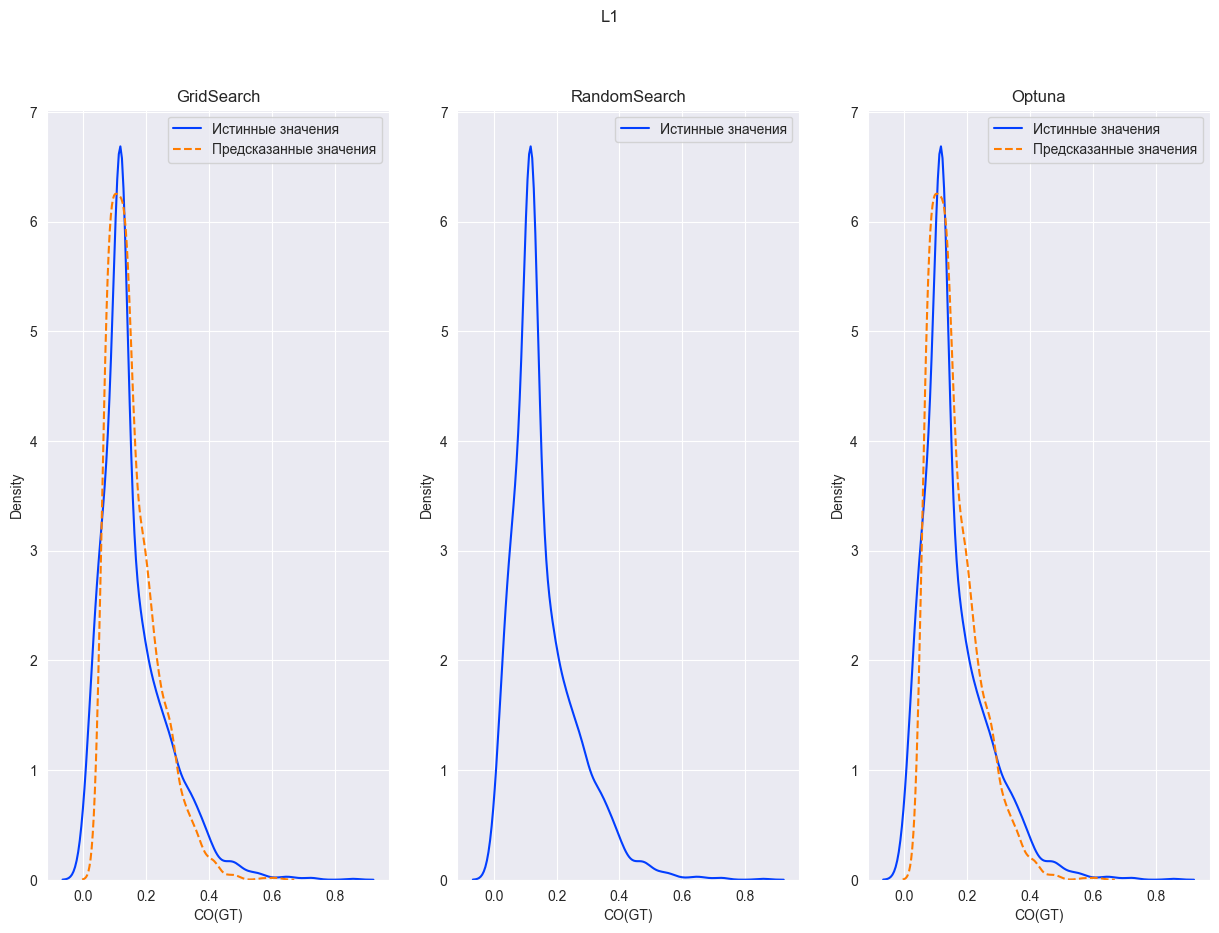

In [91]:
l1_simple_models = simple_regression_reg_result["L1"]
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, l1_simple_models.items()):
    model = model_info["model"]
    predict_on_train = model.predict(X_simple_train)
    predict_on_test = model.predict(X_simple_test)
    input_into_the_tables(f"Linear regression with L1 reg ({name_of_method})",
                      predict_on_train, y_train,
                      predict_on_test, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)


    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict_on_test, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("L1")

Заметим, что после применения L1 регуляризации с гиперпараметрами, полученными RandomSearch, все предсказания модели - константы. По этой причине невозможно построить график распределения.

Для моделей, полученными с помощью GridSearch и Optuna, визуально распределения предсказанных значений стали ближе к истинным: так, пик распределения малых значений стал ближе к фактическому распределению.

In [92]:
l1_simple_models["RandomSearch"]["model"].coef_

array([0.])

После применения RandomSearch вес для единственного признака занулился и все предсказания стали равны константе.

In [93]:
train_and_test_comparing

Train Data                    \
                                                     R2   MSE  RMSE   MAE   
Linear regression                                 0.697 0.003 0.056 0.038   
Linear regression with L1 reg (GridSearch)        0.691 0.003 0.057 0.039   
Linear regression with L1 reg (RandomSearch)      0.000 0.010 0.102 0.075   
Linear regression with L1 reg (Optuna)            0.691 0.003 0.057 0.039   

                                                               Test Data  \
                                                          MAPE        R2   
Linear regression                            1415233432122.305     0.729   
Linear regression with L1 reg (GridSearch)   1523272412599.400     0.722   
Linear regression with L1 reg (RandomSearch) 2596600853012.848    -0.001   
Linear regression with L1 reg (Optuna)       1523416750750.964     0.721   

                                                                \
                                               MSE  RMSE   MAE   
Linear regression                            0.003 0.054 0.036   
Linear regression with L1 reg (GridSearch)   0.003 0.054 0.038   
Linear regression with L1 reg (RandomSearch) 0.011 0.103 0.077   
Linear regression with L1 reg (Optuna)       0.003 0.054 0.038   

                                                                
                                                          MAPE  
Linear regression                            1173507248505.241  
Linear regression with L1 reg (GridSearch)   1294119819757.792  
Linear regression with L1 reg (RandomSearch) 2492362365411.954  
Linear regression with L1 reg (Optuna)       1294280956002.443

Видим, что метрики для модели, полученной RandomSearch, гораздо хуже метрик прочих моделей: коэффициент детерминации для нее равен нулю.

На данный момент модель без регуляризации обладает лучшими метриками.

#### L2 регуляризация

Text(0.5, 0.98, 'L2')

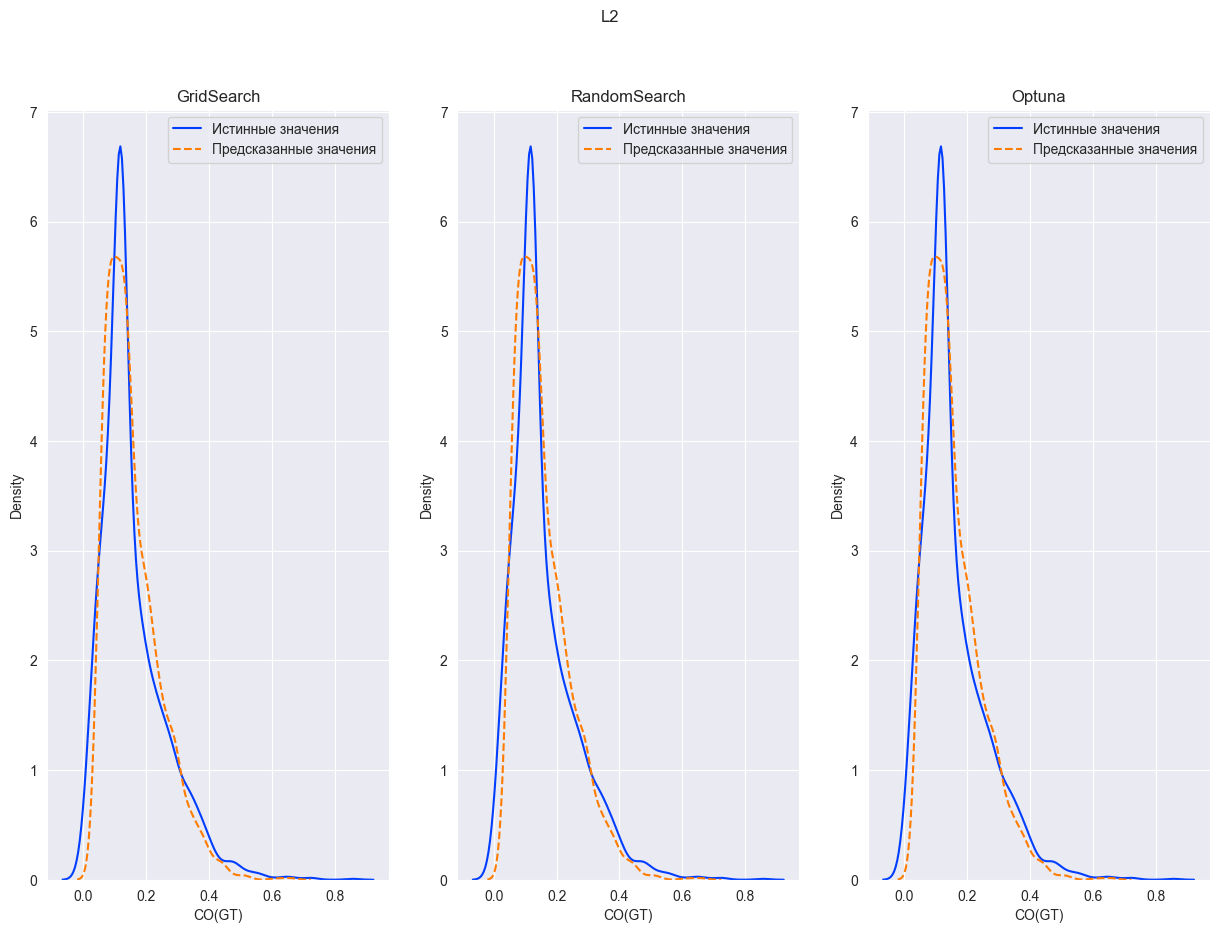

In [94]:
l2_simple_models = simple_regression_reg_result["L2"]
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, l2_simple_models.items()):
    model = model_info["model"]
    predict_on_train = model.predict(X_simple_train)
    predict_on_test = model.predict(X_simple_test)
    input_into_the_tables(f"Linear regression with L2 reg ({name_of_method})",
                      predict_on_train, y_train,
                      predict_on_test, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)


    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict_on_test, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("L2")

Видим, что визуально распределение предсказаний никак не изменилось в сравнении с моделью без регуляризации.

#### Elastic Net регуляризация

Text(0.5, 0.98, 'Elastic Net')

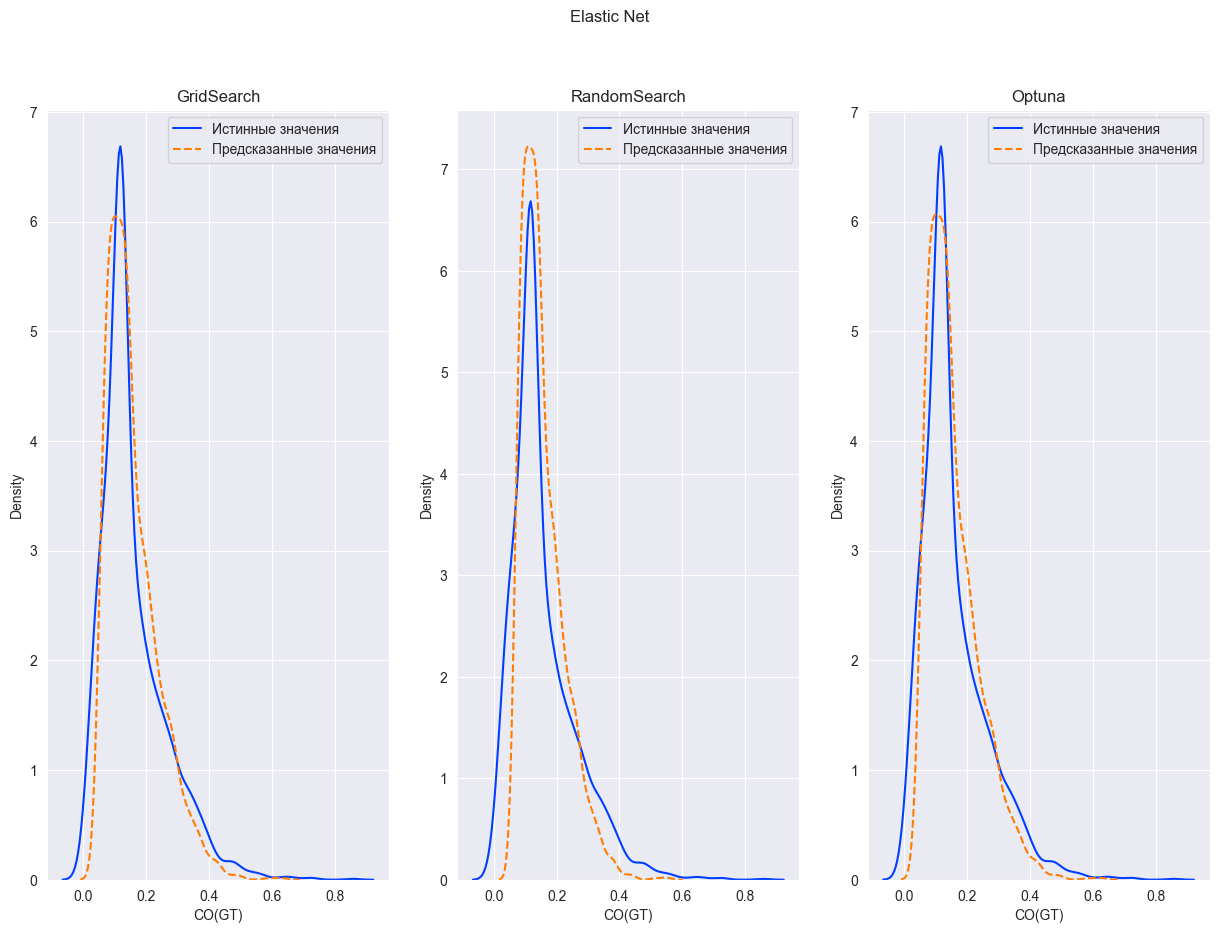

In [95]:
en_simple_models = simple_regression_reg_result["EN"]
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, en_simple_models.items()):
    model = model_info["model"]
    predict_on_train = model.predict(X_simple_train)
    predict_on_test = model.predict(X_simple_test)
    input_into_the_tables(f"Linear regression with Elastic Net reg ({name_of_method})",
                      predict_on_train, y_train,
                      predict_on_test, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)


    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict_on_test, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("Elastic Net")

С применением Elastic net регуляризации, полученной методом RandomSearch, пик малых предсказанных значений стал выше, чем для прочих моделей, полученных ранее. Кроме того, правый "хвост" распределения для предсказаний стал короче - модель стала хуже предсказывать большие значения CO.



In [96]:
train_and_test_comparing

Train Data              \
                                                           R2   MSE  RMSE   
Linear regression                                       0.697 0.003 0.056   
Linear regression with L1 reg (GridSearch)              0.691 0.003 0.057   
Linear regression with L1 reg (RandomSearch)            0.000 0.010 0.102   
Linear regression with L1 reg (Optuna)                  0.691 0.003 0.057   
Linear regression with L2 reg (GridSearch)              0.697 0.003 0.056   
Linear regression with L2 reg (RandomSearch)            0.697 0.003 0.056   
Linear regression with L2 reg (Optuna)                  0.697 0.003 0.056   
Linear regression with Elastic Net reg (GridSea...      0.694 0.003 0.056   
Linear regression with Elastic Net reg (RandomS...      0.665 0.003 0.059   
Linear regression with Elastic Net reg (Optuna)         0.694 0.003 0.056   

                                                                            \
                                                     MAE              MAPE   
Linear regression                                  0.038 1415233432122.305   
Linear regression with L1 reg (GridSearch)         0.039 1523272412599.400   
Linear regression with L1 reg (RandomSearch)       0.075 2596600853012.848   
Linear regression with L1 reg (Optuna)             0.039 1523416750750.964   
Linear regression with L2 reg (GridSearch)         0.038 1415244226733.616   
Linear regression with L2 reg (RandomSearch)       0.038 1415462338256.423   
Linear regression with L2 reg (Optuna)             0.038 1415244254360.519   
Linear regression with Elastic Net reg (GridSea... 0.039 1486785410751.889   
Linear regression with Elastic Net reg (RandomS... 0.042 1667685161658.743   
Linear regression with Elastic Net reg (Optuna)    0.039 1490055936783.195   

                                                   Test Data              \
                                                          R2   MSE  RMSE   
Linear regression                                      0.729 0.003 0.054   
Linear regression with L1 reg (GridSearch)             0.722 0.003 0.054   
Linear regression with L1 reg (RandomSearch)          -0.001 0.011 0.103   
Linear regression with L1 reg (Optuna)                 0.721 0.003 0.054   
Linear regression with L2 reg (GridSearch)             0.729 0.003 0.054   
Linear regression with L2 reg (RandomSearch)           0.729 0.003 0.054   
Linear regression with L2 reg (Optuna)                 0.729 0.003 0.054   
Linear regression with Elastic Net reg (GridSea...     0.725 0.003 0.054   
Linear regression with Elastic Net reg (RandomS...     0.693 0.003 0.057   
Linear regression with Elastic Net reg (Optuna)        0.725 0.003 0.054   

                                                                            
                                                     MAE              MAPE  
Linear regression                                  0.036 1173507248505.241  
Linear regression with L1 reg (GridSearch)         0.038 1294119819757.792  
Linear regression with L1 reg (RandomSearch)       0.077 2492362365411.954  
Linear regression with L1 reg (Optuna)             0.038 1294280956002.443  
Linear regression with L2 reg (GridSearch)         0.036 1173519299394.839  
Linear regression with L2 reg (RandomSearch)       0.036 1173762794765.393  
Linear regression with L2 reg (Optuna)             0.036 1173519330236.964  
Linear regression with Elastic Net reg (GridSea... 0.037 1253386455830.336  
Linear regression with Elastic Net reg (RandomS... 0.041 1455339343570.213  
Linear regression with Elastic Net reg (Optuna)    0.037 1257037606111.858

После применения всех видов регуляризации для простой линейной регрессии можно сделать вывод о том, что лучше всего себя показала модель без регуляризации, так как он обладает наибольшим коэффициентом R2.

## Множественная линейная регрессия

### Множественная линейная регрессия без регуляризации

In [97]:
multiple_regression = LinearRegression()
multiple_regression.fit(X_train, y_train)

predict_on_test = multiple_regression.predict(X_test)
predict_on_train = multiple_regression.predict(X_train)

multiple_regression.coef_

array([ 1.21752394e-01,  6.16529090e-01, -4.46403234e-01,  3.62993037e-01,
        8.68851139e-02,  2.47046717e-01, -3.55387066e-02, -5.79676738e-02,
       -2.84446906e-02, -4.61126799e-02,  3.16264637e-03,  4.32565113e-04,
        7.33596822e-04,  8.16447223e-04, -1.90988559e-02])

Text(0.5, 1.0, 'Множественная регрессия без регуляризации')

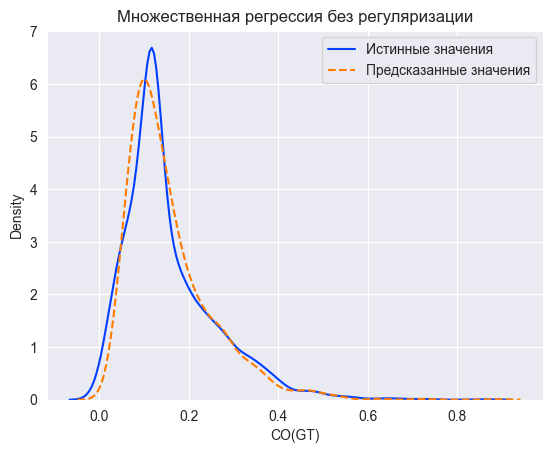

In [98]:
sns.kdeplot(y_test, label="Истинные значения")
sns.kdeplot(predict_on_test, label="Предсказанные значения", linestyle="--")

plt.legend()
plt.title("Множественная регрессия без регуляризации")

По графику видно, что модель множественной регрессии делает лучшие предсказания, чем модель простой регрессии. Приближение к малым значением стало лучше, также эта модель лучше предсказывает большие концентрации угарного газа.

In [99]:
input_into_the_tables(f"Multiple regression",
                      predict_on_train, y_train,
                      predict_on_test, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

train_and_test_comparing

Train Data              \
                                                           R2   MSE  RMSE   
Linear regression                                       0.697 0.003 0.056   
Linear regression with L1 reg (GridSearch)              0.691 0.003 0.057   
Linear regression with L1 reg (RandomSearch)            0.000 0.010 0.102   
Linear regression with L1 reg (Optuna)                  0.691 0.003 0.057   
Linear regression with L2 reg (GridSearch)              0.697 0.003 0.056   
Linear regression with L2 reg (RandomSearch)            0.697 0.003 0.056   
Linear regression with L2 reg (Optuna)                  0.697 0.003 0.056   
Linear regression with Elastic Net reg (GridSea...      0.694 0.003 0.056   
Linear regression with Elastic Net reg (RandomS...      0.665 0.003 0.059   
Linear regression with Elastic Net reg (Optuna)         0.694 0.003 0.056   
Multiple regression                                     0.831 0.002 0.042   

                                                                            \
                                                     MAE              MAPE   
Linear regression                                  0.038 1415233432122.305   
Linear regression with L1 reg (GridSearch)         0.039 1523272412599.400   
Linear regression with L1 reg (RandomSearch)       0.075 2596600853012.848   
Linear regression with L1 reg (Optuna)             0.039 1523416750750.964   
Linear regression with L2 reg (GridSearch)         0.038 1415244226733.616   
Linear regression with L2 reg (RandomSearch)       0.038 1415462338256.423   
Linear regression with L2 reg (Optuna)             0.038 1415244254360.519   
Linear regression with Elastic Net reg (GridSea... 0.039 1486785410751.889   
Linear regression with Elastic Net reg (RandomS... 0.042 1667685161658.743   
Linear regression with Elastic Net reg (Optuna)    0.039 1490055936783.195   
Multiple regression                                0.029 1422645320159.455   

                                                   Test Data              \
                                                          R2   MSE  RMSE   
Linear regression                                      0.729 0.003 0.054   
Linear regression with L1 reg (GridSearch)             0.722 0.003 0.054   
Linear regression with L1 reg (RandomSearch)          -0.001 0.011 0.103   
Linear regression with L1 reg (Optuna)                 0.721 0.003 0.054   
Linear regression with L2 reg (GridSearch)             0.729 0.003 0.054   
Linear regression with L2 reg (RandomSearch)           0.729 0.003 0.054   
Linear regression with L2 reg (Optuna)                 0.729 0.003 0.054   
Linear regression with Elastic Net reg (GridSea...     0.725 0.003 0.054   
Linear regression with Elastic Net reg (RandomS...     0.693 0.003 0.057   
Linear regression with Elastic Net reg (Optuna)        0.725 0.003 0.054   
Multiple regression                                    0.838 0.002 0.041   

                                                                            
                                                     MAE              MAPE  
Linear regression                                  0.036 1173507248505.241  
Linear regression with L1 reg (GridSearch)         0.038 1294119819757.792  
Linear regression with L1 reg (RandomSearch)       0.077 2492362365411.954  
Linear regression with L1 reg (Optuna)             0.038 1294280956002.443  
Linear regression with L2 reg (GridSearch)         0.036 1173519299394.839  
Linear regression with L2 reg (RandomSearch)       0.036 1173762794765.393  
Linear regression with L2 reg (Optuna)             0.036 1173519330236.964  
Linear regression with Elastic Net reg (GridSea... 0.037 1253386455830.336  
Linear regression with Elastic Net reg (RandomS... 0.041 1455339343570.213  
Linear regression with Elastic Net reg (Optuna)    0.037 1257037606111.858  
Multiple regression                                0.028 1100029069214.716

Метрики для модели множественной регрессии стали значительно лучше - коэффициент R2 стал равен 0.838 - значит, модель стала лучше понимать распределение CO.

Кроме того, уменьшились значения метрик MSE, RMSE, MAE в сравнении с моделью простой линейной регрессии без регуляризации.

### Множественная регрессия с регуляризацией

In [100]:
multiple_regression_reg_result = train_models_with_reg(X_train, y_train, reg_config)
multiple_regression_reg_result

{'L1': {'GridSearch': {'model': Lasso(alpha=0.001),
   'best_params': {'alpha': 0.001}},
  'RandomSearch': {'model': Lasso(alpha=0.021209508879201904),
   'best_params': {'alpha': 0.021209508879201904}},
  'Optuna': {'model': Lasso(alpha=0.0010020560170920852),
   'best_params': {'alpha': 0.0010020560170920852}}},
 'L2': {'GridSearch': {'model': Ridge(alpha=0.010481131341546858, max_iter=1000),
   'best_params': {'alpha': 0.010481131341546858}},
  'RandomSearch': {'model': Ridge(alpha=0.021209508879201904, max_iter=1000),
   'best_params': {'alpha': 0.021209508879201904}},
  'Optuna': {'model': Ridge(alpha=0.009973780546192449),
   'best_params': {'alpha': 0.009973780546192449}}},
 'EN': {'GridSearch': {'model': ElasticNet(alpha=0.001, l1_ratio=0.1),
   'best_params': {'alpha': 0.001, 'l1_ratio': 0.1}},
  'RandomSearch': {'model': ElasticNet(alpha=0.004094915062380427, l1_ratio=0.1),
   'best_params': {'l1_ratio': 0.1, 'alpha': 0.004094915062380427}},
  'Optuna': {'model': ElasticNet(a

#### L1 регуляризация

Text(0.5, 0.98, 'Multiple regression with L1')

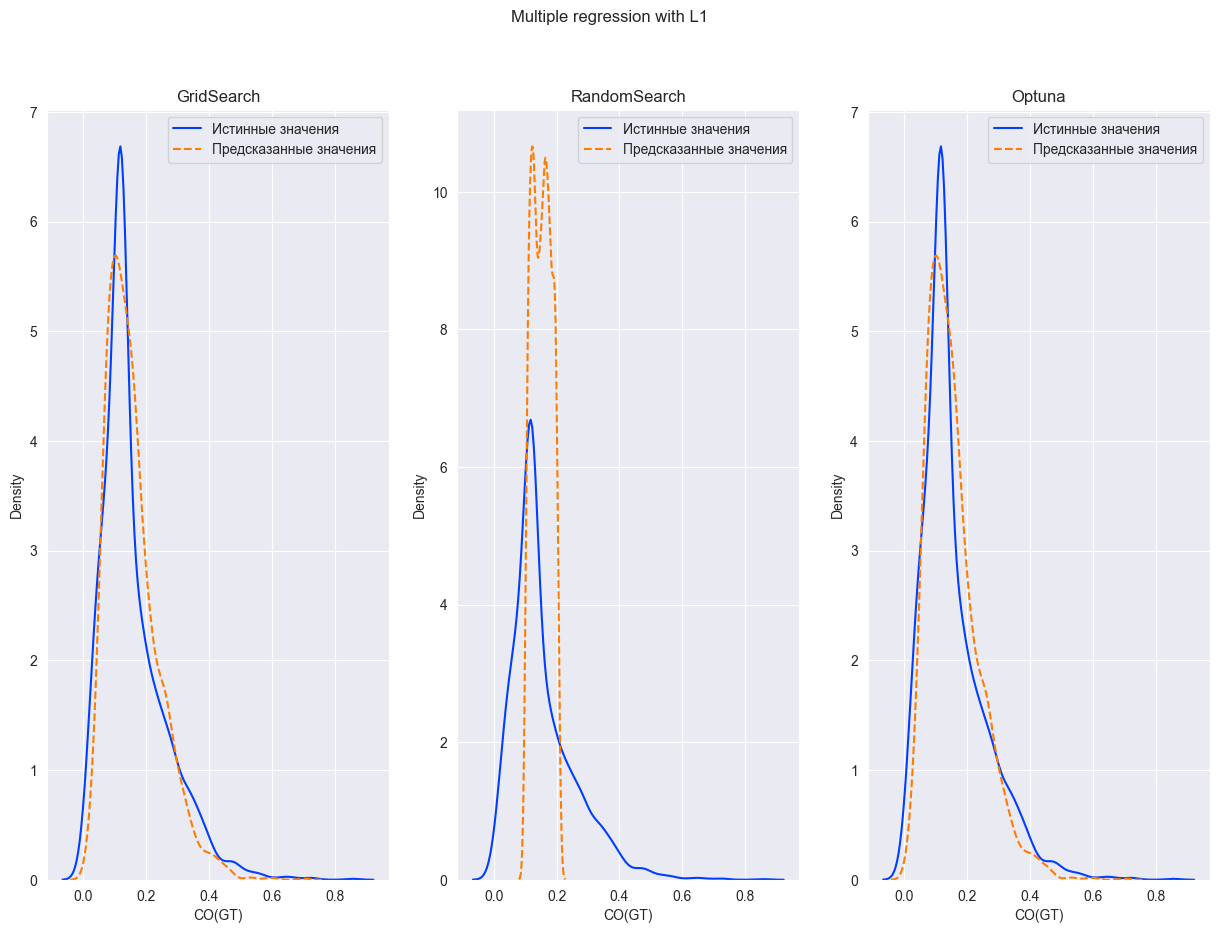

In [101]:
l1_multiple_models = multiple_regression_reg_result["L1"]
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, l1_multiple_models.items()):
    model = model_info["model"]
    predict_on_train = model.predict(X_train)
    predict_on_test = model.predict(X_test)
    input_into_the_tables(f"Multiple linear regression with L1 reg ({name_of_method})",
                      predict_on_train, y_train,
                      predict_on_test, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)


    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict_on_test, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("Multiple regression with L1")

Визуально применение L1 регуляризации (GridSearch, ElasticNet) ухудшило модель, так как пик предсказаний для малых значений стал ниже, а правый "хвост" распределения предсказаний короче: модель стала хуже предсказывать частые малые значения и редкие большие показатели.

Применение RandomSearch значительно ухудшило модель: распределение предсказаний очень отличие от истинного.

#### L2 регуляризация

Text(0.5, 0.98, 'Multiple regression with L2')

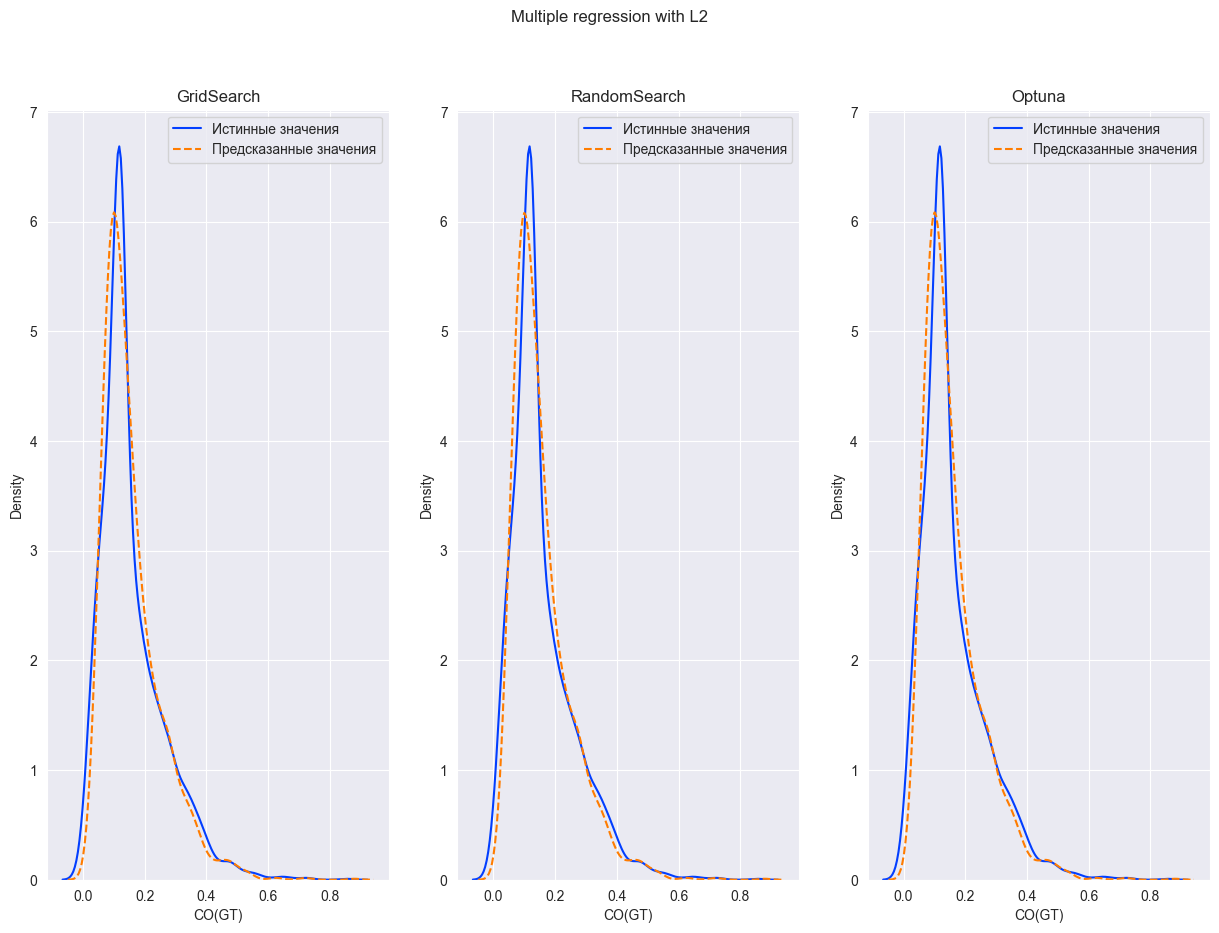

In [102]:
l2_multiple_models = multiple_regression_reg_result["L2"]
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, l2_multiple_models.items()):
    model = model_info["model"]
    predict_on_train = model.predict(X_train)
    predict_on_test = model.predict(X_test)
    input_into_the_tables(f"Multiple linear regression with L2 reg ({name_of_method})",
                      predict_on_train, y_train,
                      predict_on_test, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)


    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict_on_test, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("Multiple regression with L2")

Применение L2 регуляризации приблизило модель к истинному распределению значений CO, так как кривая распределения для предсказания близка к кривой распределения для истинных значений CO.

#### Elastic net регуляризация

Text(0.5, 0.98, 'Multiple regression with elastic net')

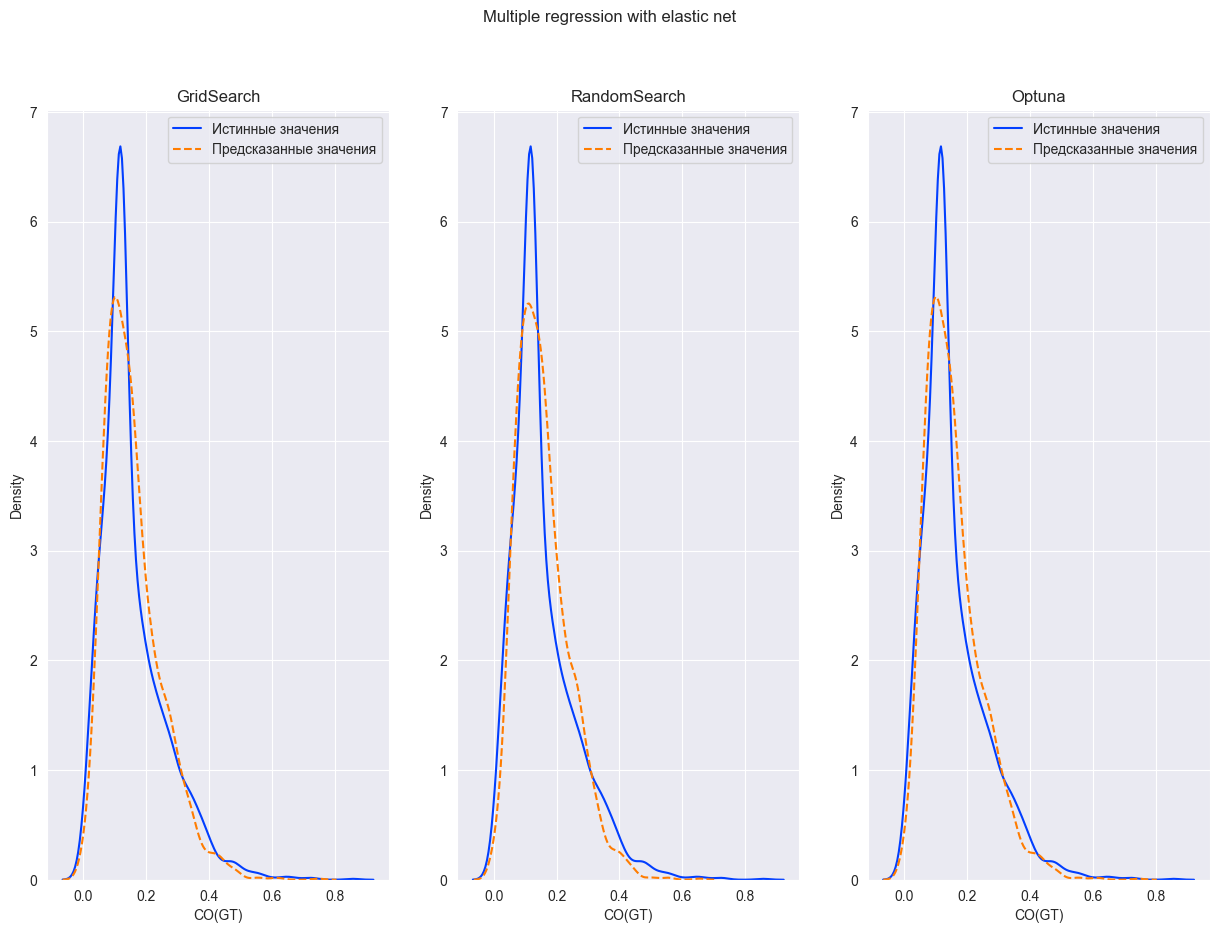

In [103]:
en_multiple_models = multiple_regression_reg_result["EN"]
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, en_multiple_models.items()):
    model = model_info["model"]
    predict_on_train = model.predict(X_train)
    predict_on_test = model.predict(X_test)
    input_into_the_tables(f"Multiple linear regression with Elastic net reg ({name_of_method})",
                      predict_on_train, y_train,
                      predict_on_test, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)


    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict_on_test, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("Multiple regression with elastic net")

Заметим, что применение ElasticNet регуляризации хуже, чем применение L2 регуляризации для данной модели, так как кривая распределения предсказаний для ElasticNet регуляризации не так хорошо приближена к фактическим значениям, как модель с L2.

In [104]:
train_and_test_comparing

Train Data              \
                                                           R2   MSE  RMSE   
Linear regression                                       0.697 0.003 0.056   
Linear regression with L1 reg (GridSearch)              0.691 0.003 0.057   
Linear regression with L1 reg (RandomSearch)            0.000 0.010 0.102   
Linear regression with L1 reg (Optuna)                  0.691 0.003 0.057   
Linear regression with L2 reg (GridSearch)              0.697 0.003 0.056   
Linear regression with L2 reg (RandomSearch)            0.697 0.003 0.056   
Linear regression with L2 reg (Optuna)                  0.697 0.003 0.056   
Linear regression with Elastic Net reg (GridSea...      0.694 0.003 0.056   
Linear regression with Elastic Net reg (RandomS...      0.665 0.003 0.059   
Linear regression with Elastic Net reg (Optuna)         0.694 0.003 0.056   
Multiple regression                                     0.831 0.002 0.042   
Multiple linear regression with L1 reg (GridSea...      0.802 0.002 0.045   
Multiple linear regression with L1 reg (RandomS...      0.107 0.009 0.097   
Multiple linear regression with L1 reg (Optuna)         0.802 0.002 0.045   
Multiple linear regression with L2 reg (GridSea...      0.831 0.002 0.042   
Multiple linear regression with L2 reg (RandomS...      0.831 0.002 0.042   
Multiple linear regression with L2 reg (Optuna)         0.831 0.002 0.042   
Multiple linear regression with Elastic net reg...      0.816 0.002 0.044   
Multiple linear regression with Elastic net reg...      0.794 0.002 0.046   
Multiple linear regression with Elastic net reg...      0.816 0.002 0.044   

                                                                            \
                                                     MAE              MAPE   
Linear regression                                  0.038 1415233432122.305   
Linear regression with L1 reg (GridSearch)         0.039 1523272412599.400   
Linear regression with L1 reg (RandomSearch)       0.075 2596600853012.848   
Linear regression with L1 reg (Optuna)             0.039 1523416750750.964   
Linear regression with L2 reg (GridSearch)         0.038 1415244226733.616   
Linear regression with L2 reg (RandomSearch)       0.038 1415462338256.423   
Linear regression with L2 reg (Optuna)             0.038 1415244254360.519   
Linear regression with Elastic Net reg (GridSea... 0.039 1486785410751.889   
Linear regression with Elastic Net reg (RandomS... 0.042 1667685161658.743   
Linear regression with Elastic Net reg (Optuna)    0.039 1490055936783.195   
Multiple regression                                0.029 1422645320159.455   
Multiple linear regression with L1 reg (GridSea... 0.031 1477186246748.700   
Multiple linear regression with L1 reg (RandomS... 0.070 2475814114638.448   
Multiple linear regression with L1 reg (Optuna)    0.031 1477448498836.864   
Multiple linear regression with L2 reg (GridSea... 0.029 1422236168536.017   
Multiple linear regression with L2 reg (RandomS... 0.029 1421822271345.906   
Multiple linear regression with L2 reg (Optuna)    0.029 1422255863794.157   
Multiple linear regression with Elastic net reg... 0.029 1369604472178.974   
Multiple linear regression with Elastic net reg... 0.031 1408328929416.410   
Multiple linear regression with Elastic net reg... 0.029 1370307553780.921   

                                                   Test Data              \
                                                          R2   MSE  RMSE   
Linear regression                                      0.729 0.003 0.054   
Linear regression with L1 reg (GridSearch)             0.722 0.003 0.054   
Linear regression with L1 reg (RandomSearch)          -0.001 0.011 0.103   
Linear regression with L1 reg (Optuna)                 0.721 0.003 0.054   
Linear regression with L2 reg (GridSearch)             0.729 0.003 0.054   
Linear regression with L2 reg (RandomSearch)           0.729 0.003 0.054   
Linear regression with L2 reg (

Лучшей моделью на данный момент оказалась модель множественной регрессии с L2 регуляризацией, полученной с помощью фреймворка Optuna, так как для нее метрики принимают лучшие значения (коэффициент R2 равен 0.839, MSE 0.002, RMSE равен 0.041.

## Полиномиальная регрессия

### Полиномиальная регрессия без регуляризации

In [105]:
poly = PolynomialFeatures(degree = 2)
X_poly2_train = poly.fit_transform(X_train)
X_poly2_test = poly.transform(X_test)
X_poly2_train.shape

(6656, 136)

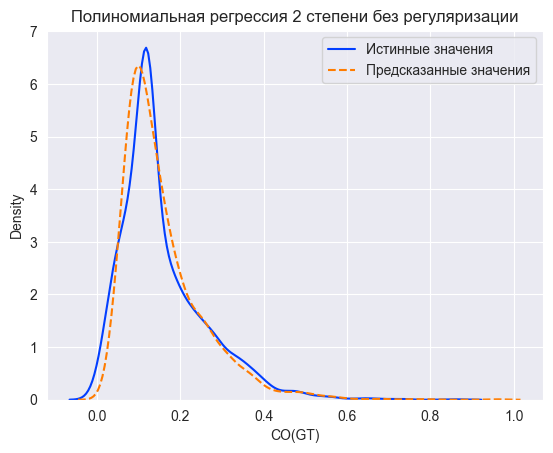

In [106]:
poly2_model = LinearRegression()
poly2_model.fit(X_poly2_train, y_train)

predict_on_test = poly2_model.predict(X_poly2_test)
predict_on_train = poly2_model.predict(X_poly2_train)

sns.kdeplot(y_test, label="Истинные значения")
sns.kdeplot(predict_on_test, label="Предсказанные значения", linestyle="--")

plt.legend()
plt.title("Полиномиальная регрессия 2 степени без регуляризации")

input_into_the_tables(f"Polynomial regression (deg = 2)",
                      predict_on_train, y_train,
                      predict_on_test, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

Видно, что модель полиномиальной регрессии 2 степени хорошо предсказывает малые значения. При этом она завышает некоторые значения, так как левый "хвост" для распределения предсказаний длиннее, чем для распределения фактических значений.

Text(0, 0.5, 'Фактические значения')

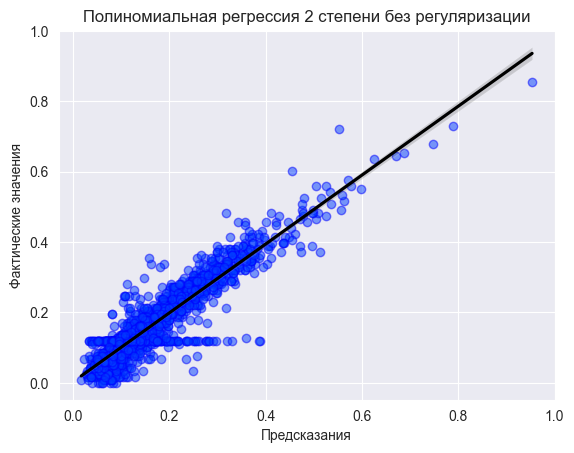

In [107]:
sns.regplot(x=predict_on_test, y=y_test, scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})
plt.title("Полиномиальная регрессия 2 степени без регуляризации")

plt.xlabel("Предсказания")
plt.ylabel("Фактические значения")

In [108]:
train_and_test_comparing.loc["Polynomial regression (deg = 2)"]

Train Data  R2                 0.852
            MSE                0.002
            RMSE               0.039
            MAE                0.027
            MAPE   1345350999355.731
Test Data   R2                 0.861
            MSE                0.001
            RMSE               0.038
            MAE                0.026
            MAPE   1055529842974.730
Name: Polynomial regression (deg = 2), dtype: float64

In [109]:
poly = PolynomialFeatures(degree = 3)
X_poly3_train = poly.fit_transform(X_train)
X_poly3_test = poly.transform(X_test)
X_poly3_train.shape

(6656, 816)

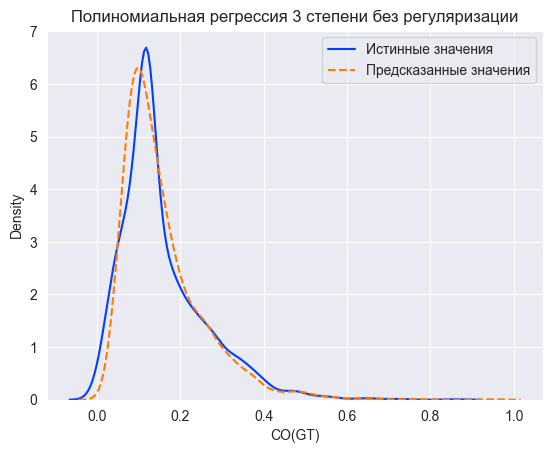

In [110]:
poly3_model = LinearRegression()
poly3_model.fit(X_poly3_train, y_train)

predict_on_test = poly3_model.predict(X_poly3_test)
predict_on_train = poly3_model.predict(X_poly3_train)

sns.kdeplot(y_test, label="Истинные значения")
sns.kdeplot(predict_on_test, label="Предсказанные значения", linestyle="--")

plt.legend()
plt.title("Полиномиальная регрессия 3 степени без регуляризации")

input_into_the_tables(f"Polynomial regression (deg = 3)",
                      predict_on_train, y_train,
                      predict_on_test, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

In [111]:
train_and_test_comparing.loc["Polynomial regression (deg = 3)"]

Train Data  R2                 0.854
            MSE                0.002
            RMSE               0.039
            MAE                0.027
            MAPE   1347761801393.590
Test Data   R2                 0.863
            MSE                0.001
            RMSE               0.038
            MAE                0.026
            MAPE   1053254010950.031
Name: Polynomial regression (deg = 3), dtype: float64

В целом модель полиномиальной степени 3 степени очень похожа на полиномиальную модель 2 степени: она также хорошо предсказывает малые значения, но некоторые предсказания больше фактических.

Text(0.5, 0, 'Предсказания')

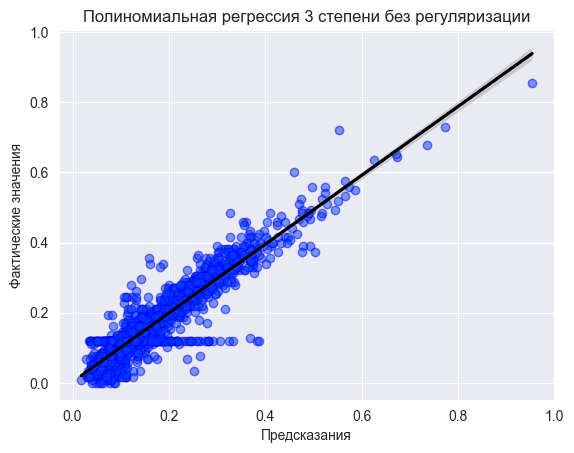

In [112]:
sns.regplot(x=predict_on_test, y=y_test, scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})
plt.title("Полиномиальная регрессия 3 степени без регуляризации")

plt.ylabel("Фактические значения")
plt.xlabel("Предсказания")

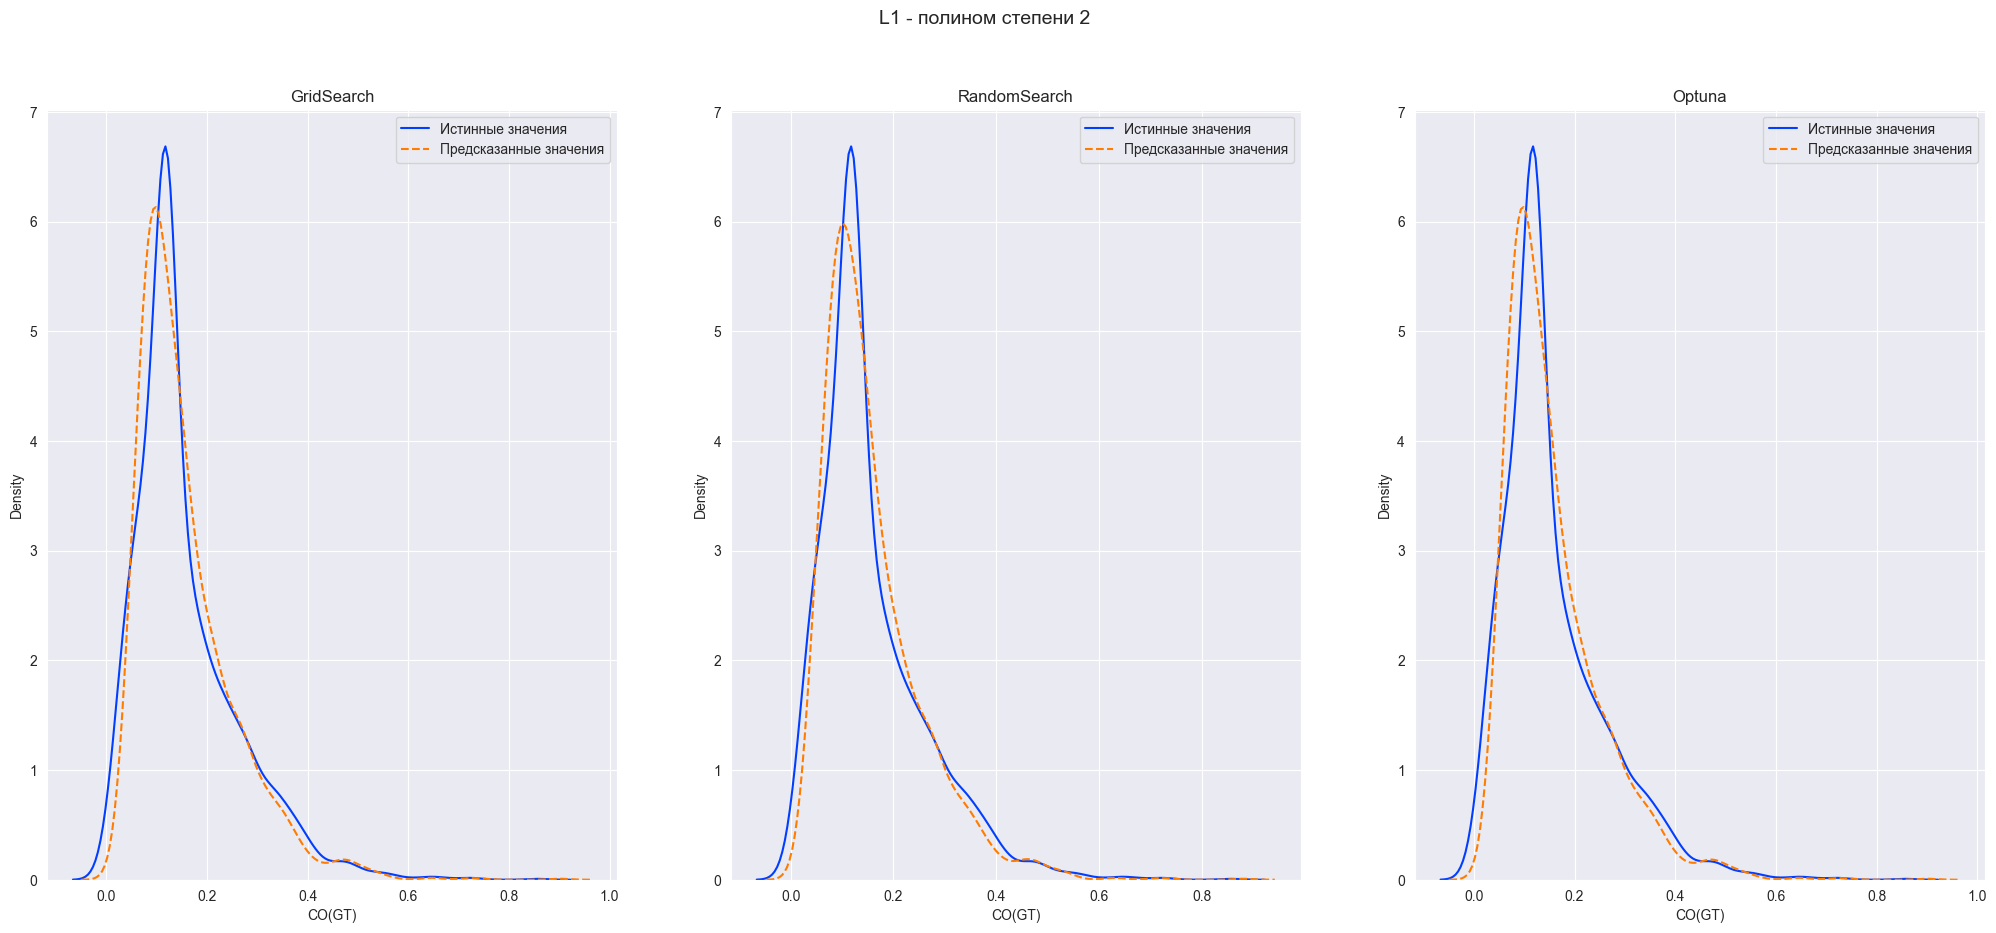

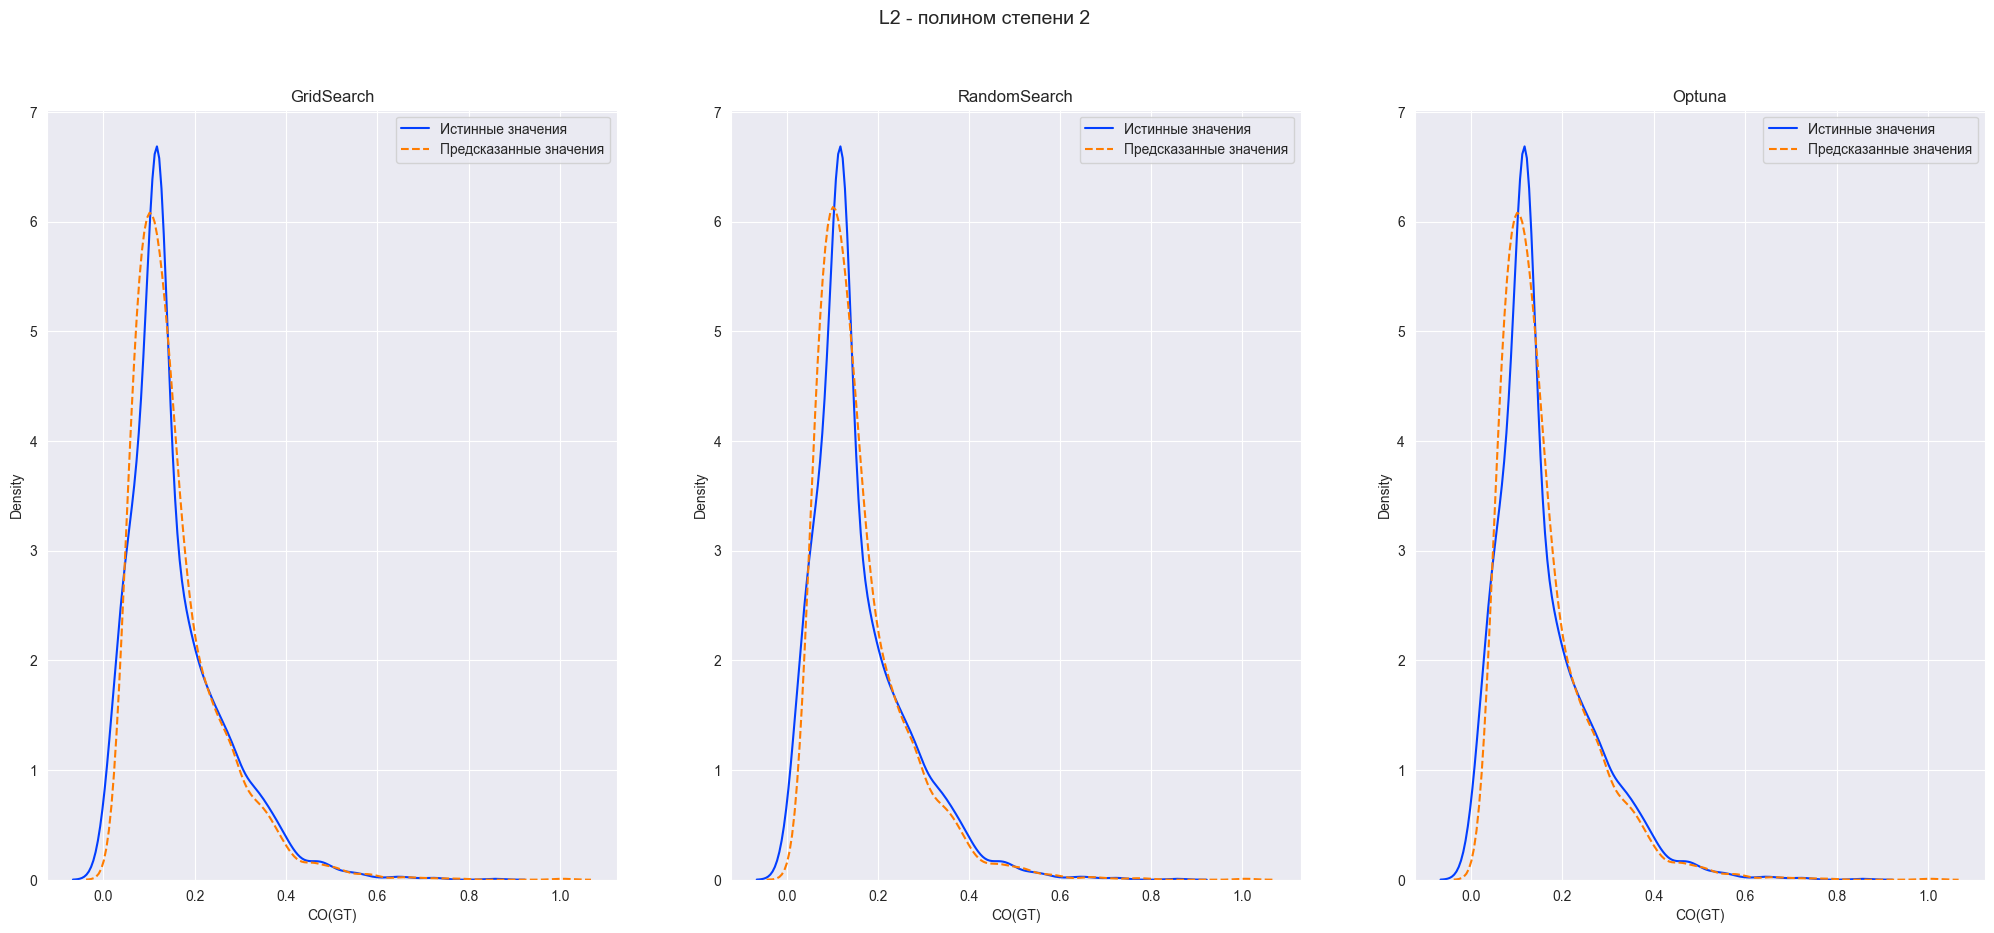

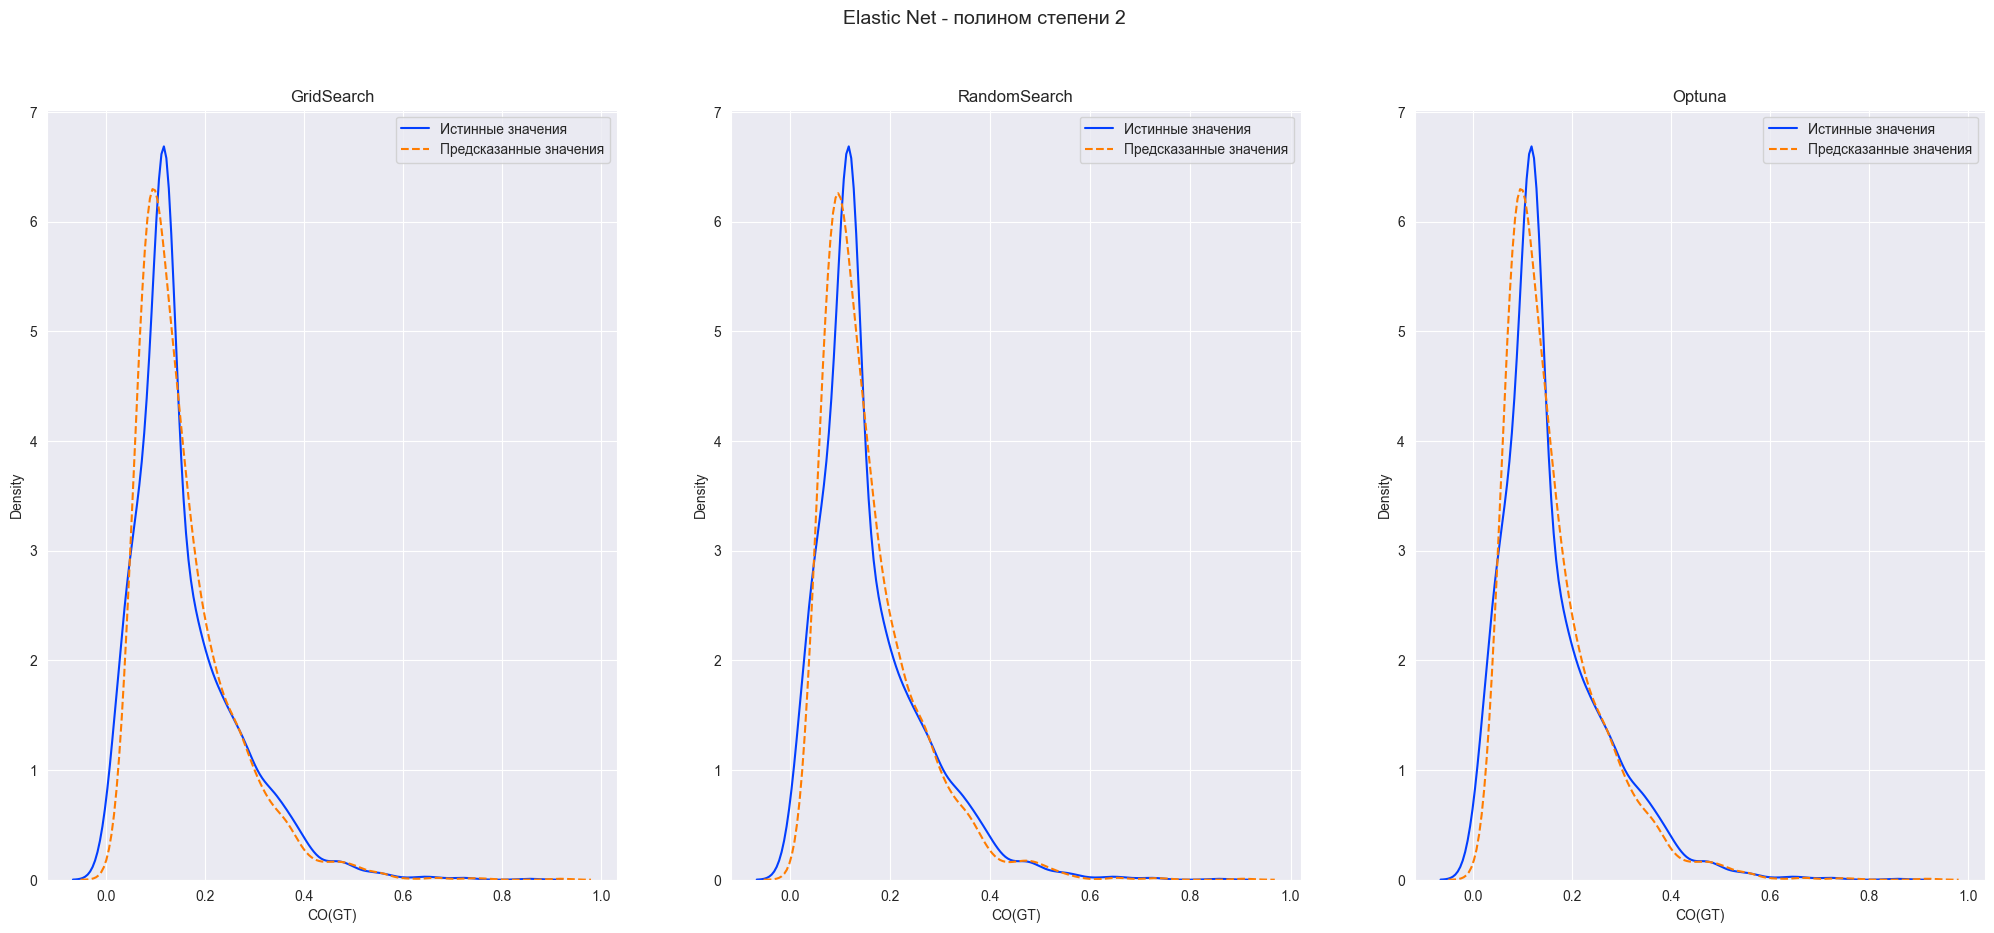

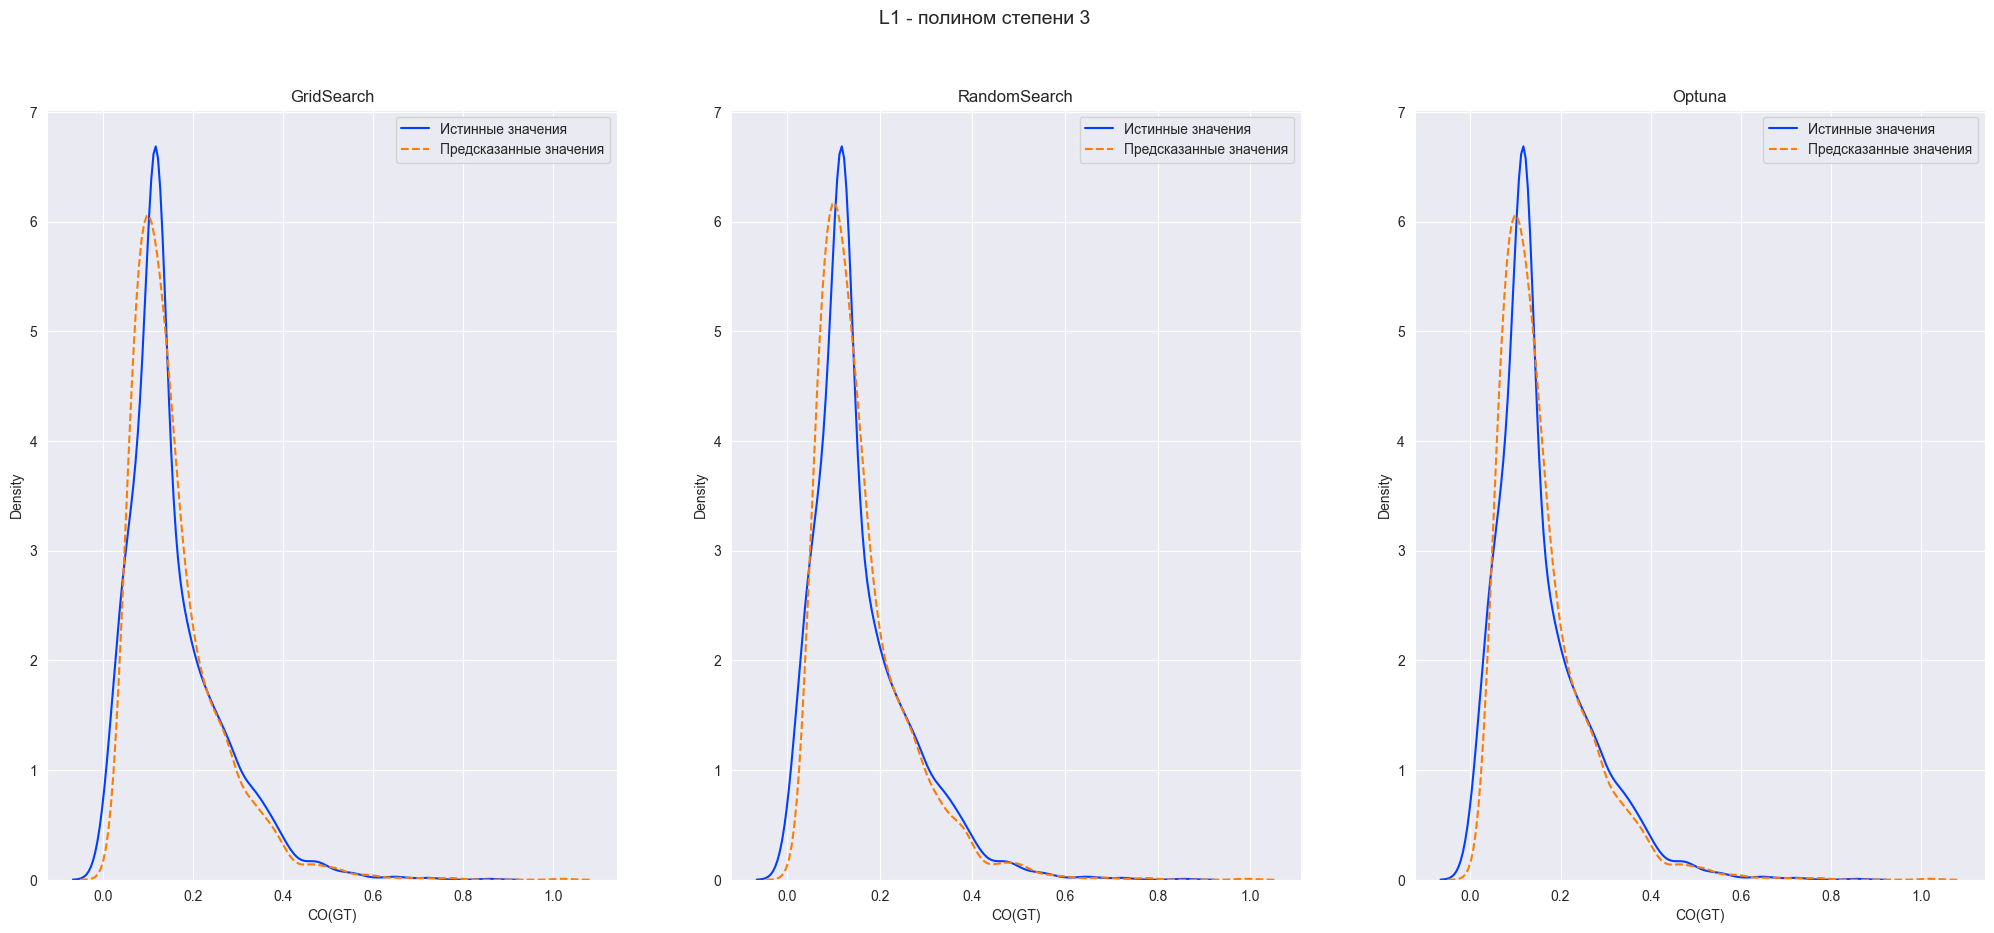

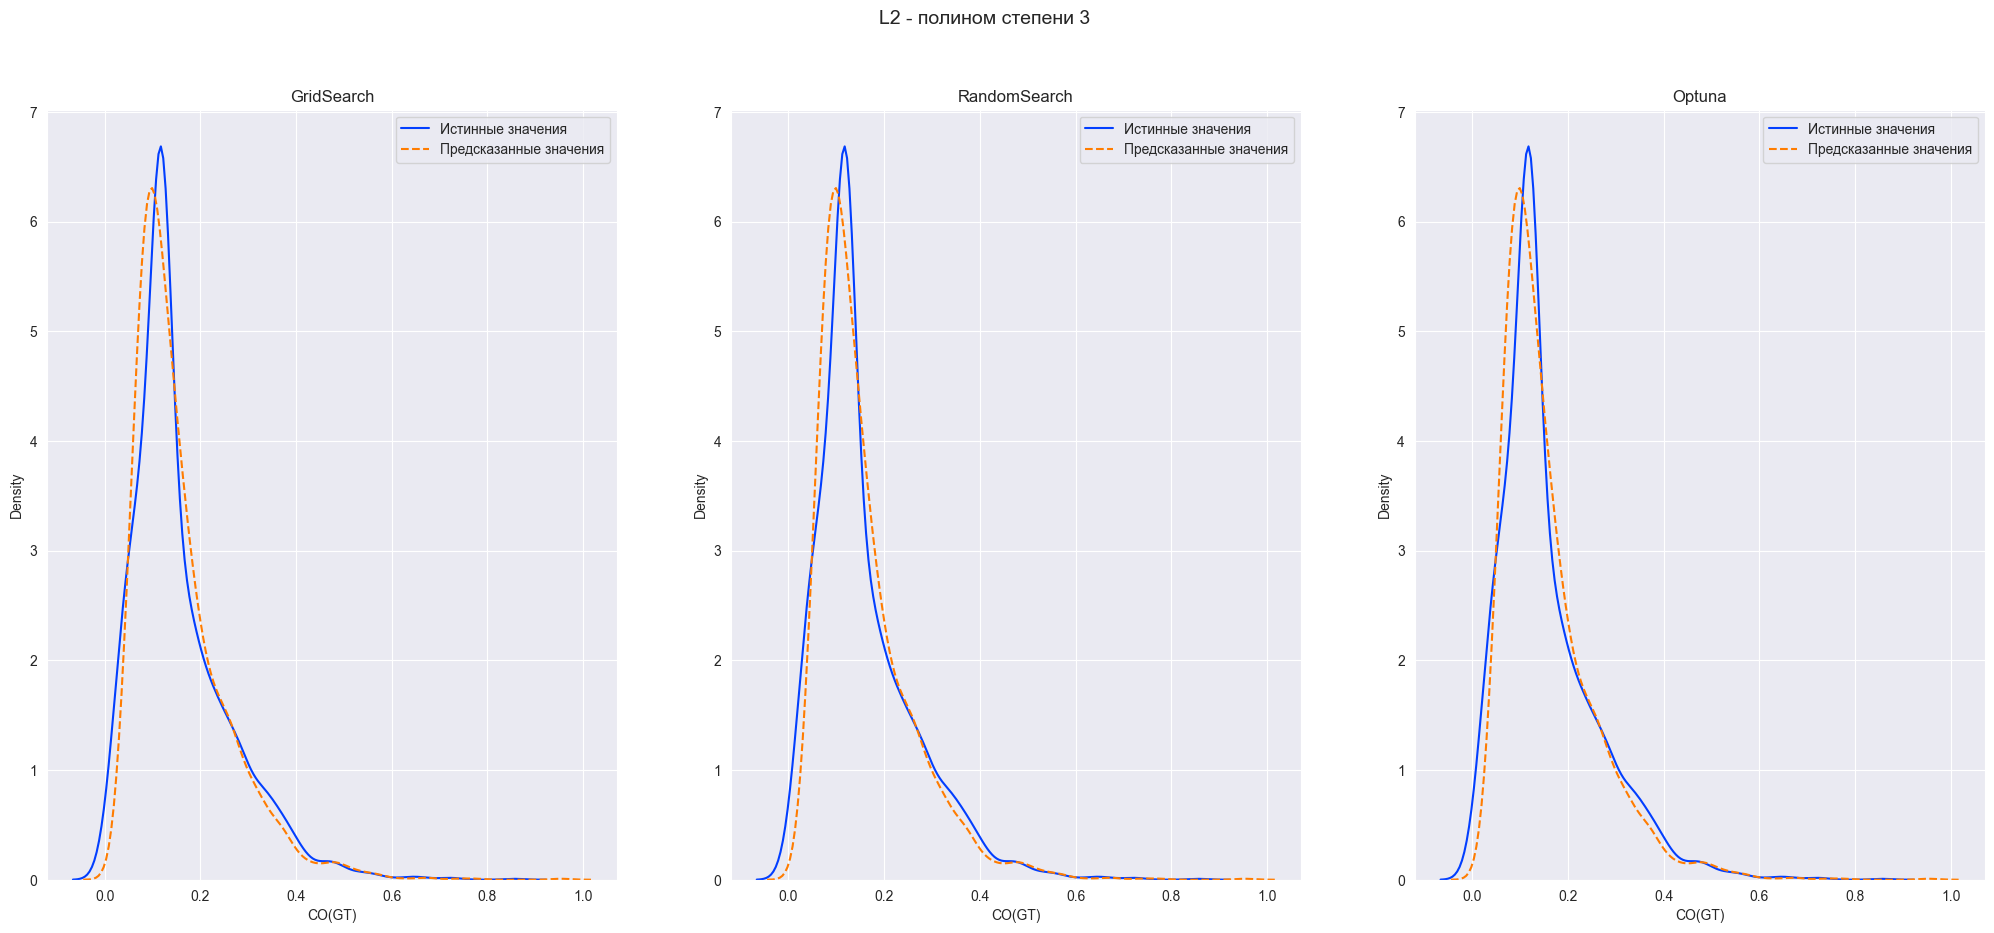

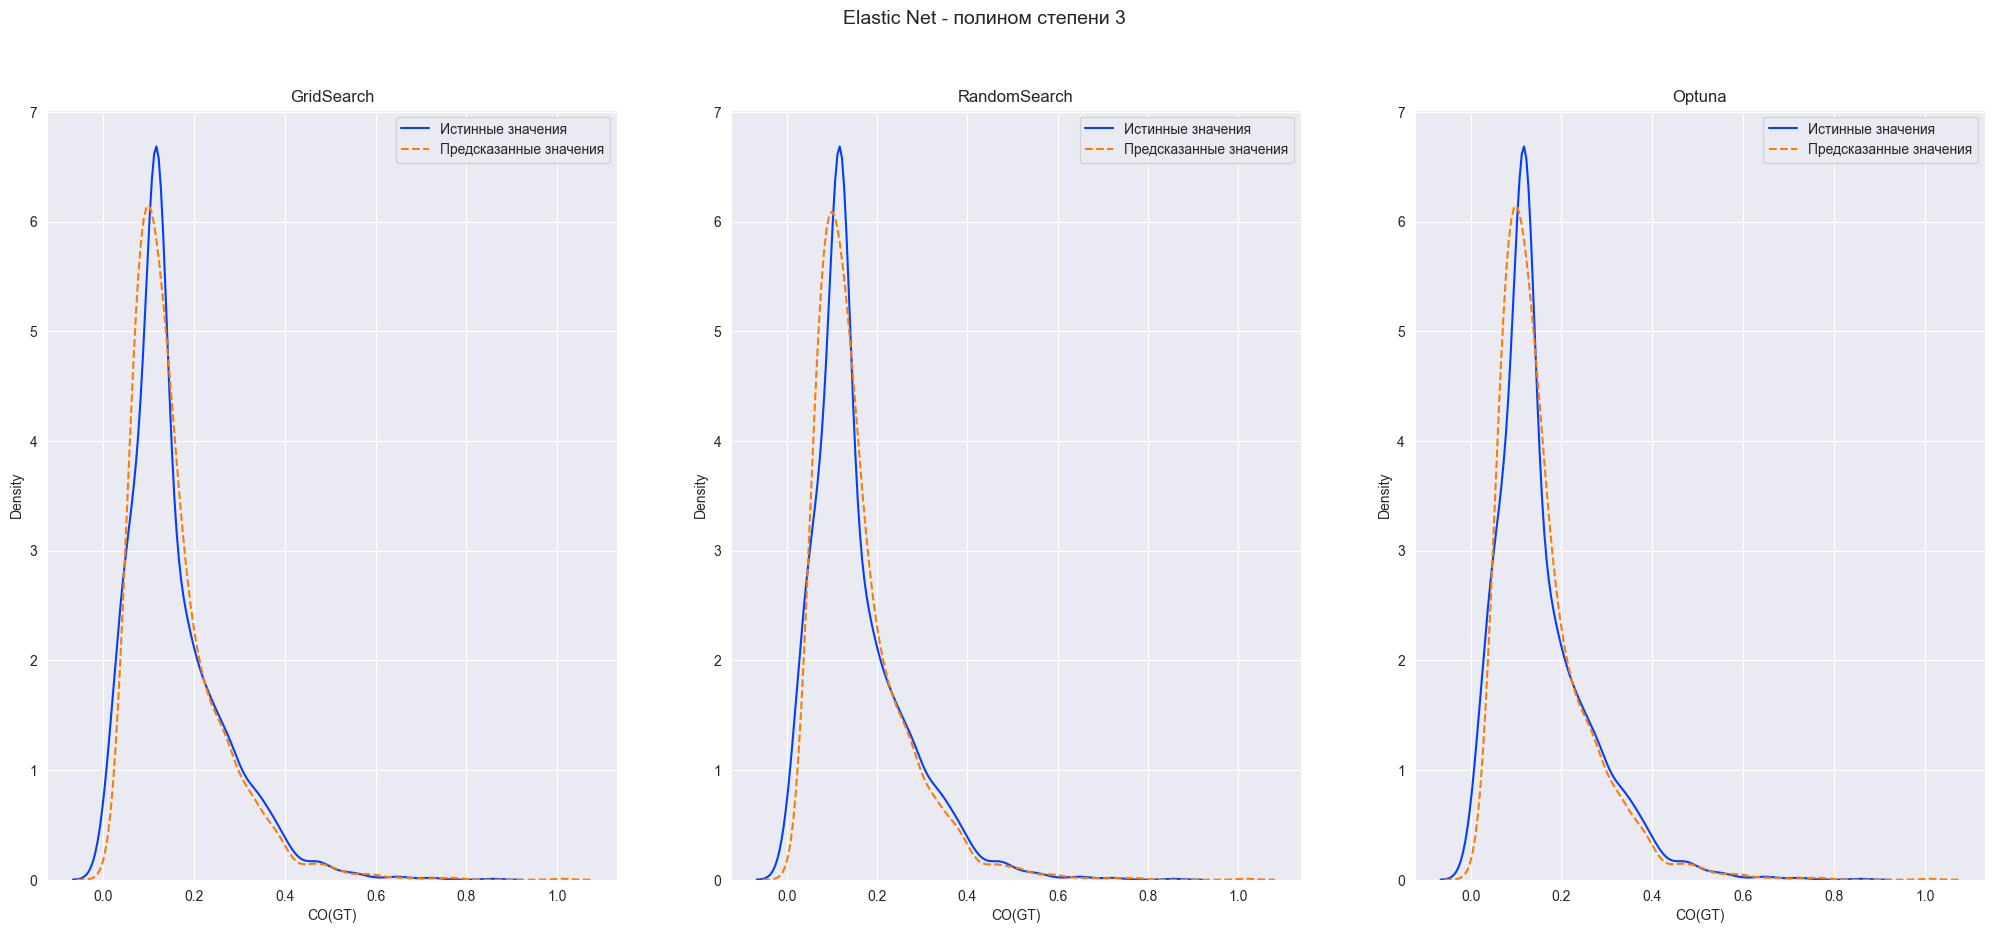

In [113]:
polynomial_X = [(X_poly2_train, X_poly2_test), (X_poly3_train, X_poly3_test)]
names=["GridSearch", "RandomSearch", "Optuna"]
results = {}

for i, (X_poly_train, X_poly_test) in enumerate(polynomial_X, start=2):
    degree = i

    models_with_regularization = train_models_with_reg(
        X_poly_train, y_train,
        reg_config
    )

    results[degree] = models_with_regularization

    l1_models = models_with_regularization["L1"]

    fig, axes = plt.subplots(1, 3, figsize=(25, 10))
    fig.suptitle(f"L1 - полином степени {degree}", fontsize=14)


    for name, ax in zip(names, axes):

        model = l1_models[name]["model"]

        train_pred = model.predict(X_poly_train)
        test_pred  = model.predict(X_poly_test)

        sns.kdeplot(y_test, ax=ax, label="Истинные значения")
        sns.kdeplot(test_pred, ax=ax, label="Предсказанные значения", linestyle="--")

        ax.set_title(name)
        ax.legend()

        key = f"Polynomial regression (deg {degree}) with L1 ({name})"
        input_into_the_tables(
            key, train_pred, y_train,
            test_pred, y_test,
            sklearn_and_custom_comparing,
            train_and_test_comparing
        )



    l2_models = models_with_regularization["L2"]

    fig, axes = plt.subplots(1, 3, figsize=(25, 10))
    fig.suptitle(f"L2 - полином степени {degree}", fontsize=14)


    for name, ax in zip(names, axes):
        model = l2_models[name]["model"]

        train_pred = model.predict(X_poly_train)
        test_pred  = model.predict(X_poly_test)

        sns.kdeplot(y_test, ax=ax, label="Истинные значения")
        sns.kdeplot(test_pred, ax=ax, label="Предсказанные значения", linestyle="--")

        ax.set_title(name)
        ax.legend()

        key = f"Polynomial regression (deg {degree}) with L2 ({name})"
        input_into_the_tables(
            key, train_pred, y_train,
            test_pred, y_test,
            sklearn_and_custom_comparing,
            train_and_test_comparing
        )



    en_models = models_with_regularization["EN"]

    fig, axes = plt.subplots(1, 3, figsize=(25, 10))
    fig.suptitle(f"Elastic Net - полином степени {degree}", fontsize=14)


    for name, ax in zip(names, axes):
        model = en_models[name]["model"]

        train_pred = model.predict(X_poly_train)
        test_pred  = model.predict(X_poly_test)

        sns.kdeplot(y_test, ax=ax, label="Истинные значения")
        sns.kdeplot(test_pred, ax=ax, label="Предсказанные значения", linestyle="--")

        ax.set_title(name)
        ax.legend()

        key = f"Polynomial regression (deg {degree}) with Elastic Net ({name})"
        input_into_the_tables(
            key, train_pred, y_train,
            test_pred, y_test,
            sklearn_and_custom_comparing,
            train_and_test_comparing
        )

Видим, что в целом графики распределений предсказаний похожи для всех полученных полиномиальных моделей с регуляризацией. Можно отметить, что для модели второй степени с L1 регуляризацией правый "хвост" распределения предсказаний не такой большой, как для прочих полиномиальных моделей.

In [114]:
train_and_test_comparing[train_and_test_comparing.index.str.startswith("Polynomial regression")].sort_values(by=("Test Data", "MSE"), ascending=True)

Train Data              \
                                                           R2   MSE  RMSE   
Polynomial regression (deg 3) with Elastic Net ...      0.885 0.001 0.035   
Polynomial regression (deg 3) with Elastic Net ...      0.884 0.001 0.035   
Polynomial regression (deg 3) with Elastic Net ...      0.881 0.001 0.035   
Polynomial regression (deg 3) with L1 (GridSearch)      0.880 0.001 0.035   
Polynomial regression (deg 3) with L1 (Optuna)          0.880 0.001 0.035   
Polynomial regression (deg 2) with L2 (Optuna)          0.876 0.001 0.036   
Polynomial regression (deg 2) with L2 (GridSearch)      0.876 0.001 0.036   
Polynomial regression (deg 2) with L2 (RandomSe...      0.874 0.001 0.036   
Polynomial regression (deg 3) with L1 (RandomSe...      0.872 0.001 0.037   
Polynomial regression (deg = 3)                         0.854 0.002 0.039   
Polynomial regression (deg 3) with L2 (GridSearch)      0.854 0.002 0.039   
Polynomial regression (deg 3) with L2 (Optuna)          0.854 0.002 0.039   
Polynomial regression (deg 3) with L2 (RandomSe...      0.854 0.002 0.039   
Polynomial regression (deg = 2)                         0.852 0.002 0.039   
Polynomial regression (deg 2) with Elastic Net ...      0.851 0.002 0.039   
Polynomial regression (deg 2) with Elastic Net ...      0.851 0.002 0.039   
Polynomial regression (deg 2) with Elastic Net ...      0.847 0.002 0.040   
Polynomial regression (deg 2) with L1 (GridSearch)      0.843 0.002 0.041   
Polynomial regression (deg 2) with L1 (Optuna)          0.843 0.002 0.041   
Polynomial regression (deg 2) with L1 (RandomSe...      0.835 0.002 0.041   

                                                                            \
                                                     MAE              MAPE   
Polynomial regression (deg 3) with Elastic Net ... 0.024 1181538017983.487   
Polynomial regression (deg 3) with Elastic Net ... 0.024 1182394007542.323   
Polynomial regression (deg 3) with Elastic Net ... 0.024 1185908080366.182   
Polynomial regression (deg 3) with L1 (GridSearch) 0.024 1209903682700.270   
Polynomial regression (deg 3) with L1 (Optuna)     0.024 1210145816811.279   
Polynomial regression (deg 2) with L2 (Optuna)     0.025 1255526995565.992   
Polynomial regression (deg 2) with L2 (GridSearch) 0.025 1255524842272.795   
Polynomial regression (deg 2) with L2 (RandomSe... 0.025 1267599588054.878   
Polynomial regression (deg 3) with L1 (RandomSe... 0.025 1298938211568.940   
Polynomial regression (deg = 3)                    0.027 1347761801393.590   
Polynomial regression (deg 3) with L2 (GridSearch) 0.027 1347762501244.249   
Polynomial regression (deg 3) with L2 (Optuna)     0.027 1347762727728.539   
Polynomial regression (deg 3) with L2 (RandomSe... 0.027 1347762684068.825   
Polynomial regression (deg = 2)                    0.027 1345350999355.731   
Polynomial regression (deg 2) with Elastic Net ... 0.027 1352016747208.347   
Polynomial regression (deg 2) with Elastic Net ... 0.027 1352030399932.736   
Polynomial regression (deg 2) with Elastic Net ... 0.027 1350986420928.317   
Polynomial regression (deg 2) with L1 (GridSearch) 0.028 1370113875776.795   
Polynomial regression (deg 2) with L1 (Optuna)     0.028 1370119747456.285   
Polynomial regression (deg 2) with L1 (RandomSe... 0.028 1408796067342.229   

                                                   Test Data              \
                                                          R2   MSE  RMSE   
Polynomial regression (deg 3) with Elastic Net ...     0.879 0.001 0.036   
Polynomial regression (deg 3) with Elastic Net ...     0.879 0.001 0.036   
Polynomial regression (deg 3) with Elastic Net ...     0.877 0.001 0.036   
Polynomial regression (deg 3) with L1 (GridSearch)     0.876 0.001 0.036   
Polynomial regression (deg 3) with L1 (Optuna)         0.876 0.001 0.036   
Polynomial regression (deg 2) with L2 (Optuna)         0.875 0.001 0.036   
Polynomial regression (deg 2) w

Лучшей моделью оказалась модель полиномиальной регрессии 3 степени с ElasticNet регуляризацией (параметры были подобраны с помощью Optuna).

Коэффициент детерминации R2 для этой модели составляет 0.879, метрика MSE - 0.001, RMSE - 0.036, MAE - 0.024.

Стоит отметить, что на тренировочной выборке модель показывает себя лучше, чем на тестовой, так как метрики для тестовой выборки метрики оказались чуть хуже. Например, коэффициент R2 для тренировочной выборки составляет 0.885. Это говорит о том, что модель для модели характерно переобучение.

Text(0.5, 1.0, 'Полиномиальная модель 3 степени с Elastic Net регуляризацией')

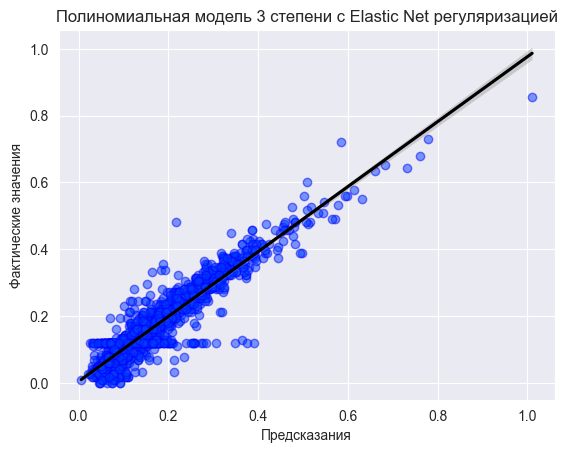

In [115]:
poly3_model_info = results[3]["EN"]["Optuna"]
poly3_model = poly3_model_info["model"]
poly3_model_params = poly3_model_info["best_params"]

sns.regplot(y=y_test, x=poly3_model.predict(X_poly3_test), scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})

plt.xlabel("Предсказания")
plt.ylabel("Фактические значения")
plt.title("Полиномиальная модель 3 степени с Elastic Net регуляризацией")

## Байесовская регрессия

In [116]:
bayesian_model = BayesianRidge()
bayesian_model.fit(X_train, y_train)
bayesian_train_predict = bayesian_model.predict(X_train)
bayesian_test_predict = bayesian_model.predict(X_test)

input_into_the_tables("Bayesian regression",
                      bayesian_train_predict, y_train,
                      bayesian_test_predict, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)


train_and_test_comparing.loc["Bayesian regression"]

Train Data  R2                 0.831
            MSE                0.002
            RMSE               0.042
            MAE                0.029
            MAPE   1421343175945.834
Test Data   R2                 0.838
            MSE                0.002
            RMSE               0.041
            MAE                0.028
            MAPE   1098333858238.889
Name: Bayesian regression, dtype: float64

Байесовская модель регрессии отработала хуже, чем модель полиномиальной регрессии, но лучше линейных моделей.

In [117]:
bayesian_range = np.logspace(-7, -2, 6).tolist()

bayesian_model_config = {"Bayesian": {
    "reg": BayesianRidge,
    "param_grid": {
        "alpha_1": bayesian_range,
        "alpha_2": bayesian_range,
        "lambda_1": bayesian_range,
        "lambda_2": bayesian_range
    }
}
}

In [118]:
bayesian_models = train_models_with_reg(
        X_train, y_train,
        bayesian_model_config
    )

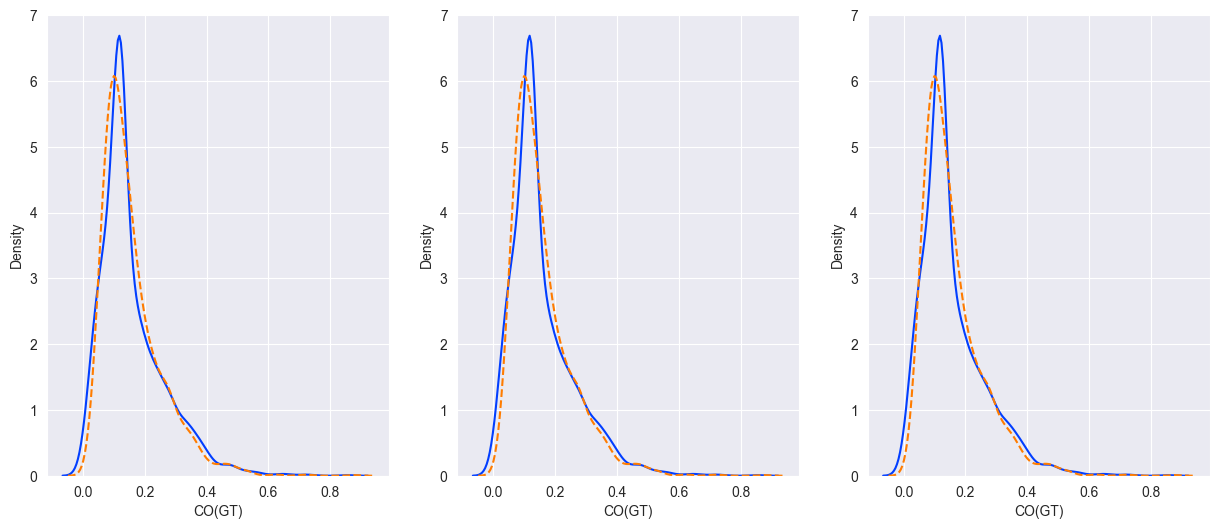

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, (name, model_info) in zip(axes, bayesian_models["Bayesian"].items()):
    model = model_info["model"]
    predict_on_train = model.predict(X_train)
    predict_on_test = model.predict(X_test)

    input_into_the_tables(f"Bayesian regression ({name})",
                      predict_on_train, y_train,
                      predict_on_test, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)


    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict_on_test, label="Предсказанные значения", linestyle="--", ax=ax)



In [120]:
train_and_test_comparing[train_and_test_comparing.index.str.startswith("Bayesian regression")]

Train Data                    \
                                           R2   MSE  RMSE   MAE   
Bayesian regression                     0.831 0.002 0.042 0.029   
Bayesian regression (GridSearch)        0.831 0.002 0.042 0.029   
Bayesian regression (RandomSearch)      0.831 0.002 0.042 0.029   
Bayesian regression (Optuna)            0.831 0.002 0.042 0.029   

                                                     Test Data              \
                                                MAPE        R2   MSE  RMSE   
Bayesian regression                1421343175945.834     0.838 0.002 0.041   
Bayesian regression (GridSearch)   1421375819048.502     0.838 0.002 0.041   
Bayesian regression (RandomSearch) 1421346518092.651     0.838 0.002 0.041   
Bayesian regression (Optuna)       1421375677597.137     0.838 0.002 0.041   

                                                            
                                     MAE              MAPE  
Bayesian regression                0.028 1098333858238.889  
Bayesian regression (GridSearch)   0.028 1098376344244.866  
Bayesian regression (RandomSearch) 0.028 1098338208119.520  
Bayesian regression (Optuna)       0.028 1098376160140.372

Настройка гиперпараметров практически никак не повлияла на метрики модели Байесовской регрессии.

## Робастная регрессия

In [121]:
huber_model = HuberRegressor(max_iter=10000)
huber_model.fit(X_train, y_train)
huber_train_predict = huber_model.predict(X_train)
huber_test_predict = huber_model.predict(X_test)

input_into_the_tables("Huber regression",
                      huber_train_predict, y_train,
                      huber_test_predict, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

train_and_test_comparing.loc["Huber regression"]

Train Data  R2                 0.806
            MSE                0.002
            RMSE               0.045
            MAE                0.030
            MAPE   1353287571158.446
Test Data   R2                 0.824
            MSE                0.002
            RMSE               0.043
            MAE                0.028
            MAPE   1016618390827.274
Name: Huber regression, dtype: float64

Модель робастной регрессии показывает результаты хуже, чем модель байсовской регрессии или полиномиальная модель.

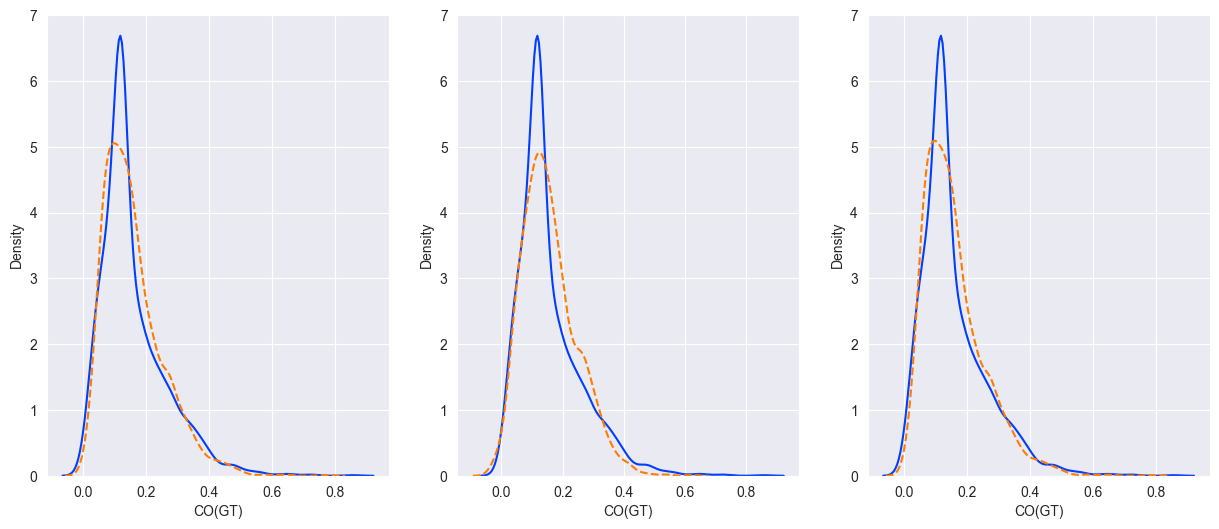

In [122]:
epsilon_range = np.linspace(1, 2, 5).tolist()

alpha_robust = np.logspace(-4, 2, 10).tolist()

huber_config = {
    "Huber":{
    "reg": HuberRegressor,
    "param_grid": {
        "epsilon": epsilon_range,
        "alpha": alpha_robust,
        "max_iter": [10000]
    }
}
}
huber_models = train_models_with_reg(
        X_train, y_train,
        huber_config
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, (name, model_info) in zip(axes, huber_models["Huber"].items()):
    model = model_info["model"]
    predict_on_train = model.predict(X_train)
    predict_on_test = model.predict(X_test)

    input_into_the_tables(f"Huber regression ({name})",
                      predict_on_train, y_train,
                      predict_on_test, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)


    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict_on_test, label="Предсказанные значения", linestyle="--", ax=ax)


In [123]:
train_and_test_comparing[train_and_test_comparing.index.str.startswith("Huber regression")]

Train Data                    \
                                        R2   MSE  RMSE   MAE   
Huber regression                     0.806 0.002 0.045 0.030   
Huber regression (GridSearch)        0.813 0.002 0.044 0.029   
Huber regression (RandomSearch)      0.756 0.003 0.051 0.035   
Huber regression (Optuna)            0.814 0.002 0.044 0.029   

                                                  Test Data                    \
                                             MAPE        R2   MSE  RMSE   MAE   
Huber regression                1353287571158.446     0.824 0.002 0.043 0.028   
Huber regression (GridSearch)   1374671238331.010     0.828 0.002 0.043 0.028   
Huber regression (RandomSearch) 1323173764265.382     0.776 0.002 0.049 0.033   
Huber regression (Optuna)       1379705513658.604     0.829 0.002 0.043 0.028   

                                                   
                                             MAPE  
Huber regression                1016618390827.274  
Huber regression (GridSearch)   1049157708578.959  
Huber regression (RandomSearch) 1022228156145.204  
Huber regression (Optuna)       1047880581535.267

Модель после применения гиперпараметров, полученных с помощью GridSearch и Optuna, улучшила свои метрики. Гиперпараметры, полученные с помощью RandomSearch, ухудшили модель.

## Вывод

### Выбор лучшей модели

In [124]:
train_and_test_comparing.sort_values(by=("Test Data", "R2"), ascending=False)

Train Data              \
                                                           R2   MSE  RMSE   
Polynomial regression (deg 3) with Elastic Net ...      0.885 0.001 0.035   
Polynomial regression (deg 3) with Elastic Net ...      0.884 0.001 0.035   
Polynomial regression (deg 3) with Elastic Net ...      0.881 0.001 0.035   
Polynomial regression (deg 3) with L1 (GridSearch)      0.880 0.001 0.035   
Polynomial regression (deg 3) with L1 (Optuna)          0.880 0.001 0.035   
Polynomial regression (deg 2) with L2 (Optuna)          0.876 0.001 0.036   
Polynomial regression (deg 2) with L2 (GridSearch)      0.876 0.001 0.036   
Polynomial regression (deg 2) with L2 (RandomSe...      0.874 0.001 0.036   
Polynomial regression (deg 3) with L1 (RandomSe...      0.872 0.001 0.037   
Polynomial regression (deg = 3)                         0.854 0.002 0.039   
Polynomial regression (deg 3) with L2 (GridSearch)      0.854 0.002 0.039   
Polynomial regression (deg 3) with L2 (Optuna)          0.854 0.002 0.039   
Polynomial regression (deg 3) with L2 (RandomSe...      0.854 0.002 0.039   
Polynomial regression (deg = 2)                         0.852 0.002 0.039   
Polynomial regression (deg 2) with Elastic Net ...      0.851 0.002 0.039   
Polynomial regression (deg 2) with Elastic Net ...      0.851 0.002 0.039   
Polynomial regression (deg 2) with Elastic Net ...      0.847 0.002 0.040   
Polynomial regression (deg 2) with L1 (GridSearch)      0.843 0.002 0.041   
Polynomial regression (deg 2) with L1 (Optuna)          0.843 0.002 0.041   
Polynomial regression (deg 2) with L1 (RandomSe...      0.835 0.002 0.041   
Bayesian regression                                     0.831 0.002 0.042   
Bayesian regression (RandomSearch)                      0.831 0.002 0.042   
Bayesian regression (Optuna)                            0.831 0.002 0.042   
Bayesian regression (GridSearch)                        0.831 0.002 0.042   
Multiple linear regression with L2 reg (RandomS...      0.831 0.002 0.042   
Multiple linear regression with L2 reg (GridSea...      0.831 0.002 0.042   
Multiple linear regression with L2 reg (Optuna)         0.831 0.002 0.042   
Multiple regression                                     0.831 0.002 0.042   
Huber regression (Optuna)                               0.814 0.002 0.044   
Multiple linear regression with Elastic net reg...      0.816 0.002 0.044   
Multiple linear regression with Elastic net reg...      0.816 0.002 0.044   
Huber regression (GridSearch)                           0.813 0.002 0.044   
Huber regression                                        0.806 0.002 0.045   
Multiple linear regression with L1 reg (GridSea...      0.802 0.002 0.045   
Multiple linear regression with L1 reg (Optuna)         0.802 0.002 0.045   
Multiple linear regression with Elastic net reg...      0.794 0.002 0.046   
Huber regression (RandomSearch)                         0.756 0.003 0.051   
Linear regression                                       0.697 0.003 0.056   
Linear regression with L2 reg (GridSearch)              0.697 0.003 0.056   
Linear regression with L2 reg (Optuna)                  0.697 0.003 0.056   
Linear regression with L2 reg (RandomSearch)            0.697 0.003 0.056   
Linear regression with Elastic Net reg (GridSea...      0.694 0.003 0.056   
Linear regression with Elastic Net reg (Optuna)         0.694 0.003 0.056   
Linear regression with L1 reg (GridSearch)              0.691 0.003 0.057   
Linear regression with L1 reg (Optuna)                  0.691 0.003 0.057   
Linear regression with Elastic Net reg (RandomS...      0.665 0.003 0.059   
Multiple linear regression with L1 reg (RandomS...      0.107 0.009 0.097   
Linear regression with L1 reg (RandomSearch)            0.000 0.010 0.102   

                                                                            \
                                                     MAE              MAPE   
Polynomial regression (deg 3) with Elastic N

Лучшей моделью оказалась модель полиномиальной регрессии 3 степени с Elastic Net регуляризацией (гиперпараметры были получены с помощью фреймворка Optuna).

Коэффициент детерминации R2 для этой модели составляет 0.879, метрика MSE - 0.001, RMSE - 0.036, MAE - 0.024.

Стоит отметить, что на тренировочной выборке модель показывает себя лучше, чем на тестовой, так как метрики для тестовой выборки метрики оказались чуть хуже. Например, коэффициент R2 для тренировочной выборки составляет 0.885. Это говорит о том, что модель для модели характерно переобучение.

Кроме того, можно сказать, что модели множественной регрессии с L2 регуляризацией показали себя лучше, чем модели с робастной регрессией. Байесовские модели показали себя лучше любых линейных моделей.

Стоит заметить, что метрики для полиномиальной модели 3 степени с Elastic Net регуляризацией, полученные с помощью Optuna и GridSearch, показывают практические одинаковые метрики, кроме MAPE. В силу этого лучшей моделью была выбрана модель, полученная с помощью Optuna.

Построим пайплайн для лучшей модели.

### Построение пайплайна

In [125]:
poly3_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("poly", PolynomialFeatures(degree=3)),
    ("ridge", ElasticNet(poly3_model_params))
])

### Восстановление уравнения регрессии

In [126]:
b0 = poly3_model.intercept_
coefs = poly3_model.coef_

features = poly.get_feature_names_out()

regression_eq = [f"{b0: .6f}"]
for feature, coef in zip(features, coefs):
    if coef != 0:
        sign = " + " if coef > 0 else " - "
        coef = abs(coef)
        regression_eq.append(f"{sign}{coef: .6f} * {feature}")

equation = "y = " + "".join(regression_eq)
equation

'y =  38.246043 +  0.002574 * hour +  0.003148 * PT08.S1(CO) hour +  0.000125 * PT08.S1(CO) year +  0.000060 * C6H6(GT) year +  0.000003 * PT08.S2(NMHC) year +  0.000214 * NOx(GT) year -  0.000020 * NO2(GT) year -  0.000083 * PT08.S4(NO2) year +  0.000020 * PT08.S5(O3) year +  0.000058 * T year +  0.000641 * RH month +  0.000040 * RH year +  0.000014 * AH year +  0.000003 * day year -  0.000121 * month^2 -  0.000112 * month day_of_week +  0.000249 * month hour -  0.000001 * month year -  0.000183 * day_of_week hour +  0.000000 * day_of_week year -  0.000026 * hour^2 -  0.000001 * hour year -  0.000009 * year^2 +  0.000048 * PT08.S1(CO)^2 year -  0.000214 * PT08.S1(CO) C6H6(GT) year +  0.000095 * PT08.S1(CO) PT08.S2(NMHC) year +  0.000007 * PT08.S1(CO) NOx(GT) year +  0.000002 * PT08.S1(CO) NO2(GT) year +  0.000136 * PT08.S1(CO) PT08.S4(NO2) year +  0.000503 * PT08.S1(CO) PT08.S5(O3) month +  0.000013 * PT08.S1(CO) PT08.S5(O3) year -  0.000251 * PT08.S1(CO) T year +  0.000107 * PT08.S1(

In [127]:
sklearn_and_custom_comparing

Scikit-learn              \
                                                             R2   MSE  RMSE   
Linear regression                                         0.729 0.003 0.054   
Linear regression with L1 reg (GridSearch)                0.722 0.003 0.054   
Linear regression with L1 reg (RandomSearch)             -0.001 0.011 0.103   
Linear regression with L1 reg (Optuna)                    0.721 0.003 0.054   
Linear regression with L2 reg (GridSearch)                0.729 0.003 0.054   
Linear regression with L2 reg (RandomSearch)              0.729 0.003 0.054   
Linear regression with L2 reg (Optuna)                    0.729 0.003 0.054   
Linear regression with Elastic Net reg (GridSea...        0.725 0.003 0.054   
Linear regression with Elastic Net reg (RandomS...        0.693 0.003 0.057   
Linear regression with Elastic Net reg (Optuna)           0.725 0.003 0.054   
Multiple regression                                       0.838 0.002 0.041   
Multiple linear regression with L1 reg (GridSea...        0.813 0.002 0.045   
Multiple linear regression with L1 reg (RandomS...        0.117 0.009 0.097   
Multiple linear regression with L1 reg (Optuna)           0.812 0.002 0.045   
Multiple linear regression with L2 reg (GridSea...        0.838 0.002 0.041   
Multiple linear regression with L2 reg (RandomS...        0.838 0.002 0.041   
Multiple linear regression with L2 reg (Optuna)           0.838 0.002 0.041   
Multiple linear regression with Elastic net reg...        0.829 0.002 0.043   
Multiple linear regression with Elastic net reg...        0.808 0.002 0.045   
Multiple linear regression with Elastic net reg...        0.828 0.002 0.043   
Polynomial regression (deg = 2)                           0.861 0.001 0.038   
Polynomial regression (deg = 3)                           0.863 0.001 0.038   
Polynomial regression (deg 2) with L1 (GridSearch)        0.850 0.002 0.040   
Polynomial regression (deg 2) with L1 (RandomSe...        0.841 0.002 0.041   
Polynomial regression (deg 2) with L1 (Optuna)            0.850 0.002 0.040   
Polynomial regression (deg 2) with L2 (GridSearch)        0.875 0.001 0.036   
Polynomial regression (deg 2) with L2 (RandomSe...        0.875 0.001 0.036   
Polynomial regression (deg 2) with L2 (Optuna)            0.875 0.001 0.036   
Polynomial regression (deg 2) with Elastic Net ...        0.860 0.001 0.039   
Polynomial regression (deg 2) with Elastic Net ...        0.855 0.002 0.039   
Polynomial regression (deg 2) with Elastic Net ...        0.860 0.001 0.039   
Polynomial regression (deg 3) with L1 (GridSearch)        0.876 0.001 0.036   
Polynomial regression (deg 3) with L1 (RandomSe...        0.873 0.001 0.037   
Polynomial regression (deg 3) with L1 (Optuna)            0.876 0.001 0.036   
Polynomial regression (deg 3) with L2 (GridSearch)        0.863 0.001 0.038   
Polynomial regression (deg 3) with L2 (RandomSe...        0.863 0.001 0.038   
Polynomial regression (deg 3) with L2 (Optuna)            0.863 0.001 0.038   
Polynomial regression (deg 3) with Elastic Net ...        0.879 0.001 0.036   
Polynomial regression (deg 3) with Elastic Net ...        0.877 0.001 0.036   
Polynomial regression (deg 3) with Elastic Net ...        0.879 0.001 0.036   
Bayesian regression                                       0.838 0.002 0.041   
Bayesian regression (GridSearch)                          0.838 0.002 0.041   
Bayesian regression (RandomSearch)                        0.838 0.002 0.041   
Bayesian regression (Optuna)                              0.838 0.002 0.041   
Huber regression                                          0.824 0.002 0.043   
Huber regression (GridSearch)                             0.828 0.002 0.043   
Huber regression (RandomSearch)                           0.776 0.002 0.049   
Huber regression (Optuna)                                 0.829 0.002 0.043   

                                                                            \
                      

### Интеллект-карта

![](pictures/mind_map.png)